# Eksperyment 2: 
## Odszumianie i rekonstrukcja metodą SDEdit.

Celem poniższego eksperymentu jest ocena zdolności trzech różnych architektur sieci neuronowych (Multi-Layer Perceptron, Conv1D oraz U-Net 1D) do dokładnego odszumiania (denoisingu) i rekonstrukcji znormalizowanych funkcji matematycznych, wykorzystując w tym celu modele dyfuzyjne (DDPM) zintegrowane z techniką SDEdit. 

W tej fazie badana jest **odporność modeli na zakłócenia (robustness)** oraz ich zdolność do odzyskania informacji z sygnału celowo zdegradowanego gęstym szumem gaussowskim o zadanej amplitudzie. Eksperyment ten weryfikuje praktyczną użyteczność poszczególnych architektur w warunkach imitujących rzeczywiste, zaszumione pomiary, opierając się na znajomości rozkładu danych wyuczonej przez modele w poprzednim etapie (patrz notebook 1. eksperyment_generacja...).

In [1]:
import numpy as np
import itertools
import time
import pandas as pd
import os
import sys
import copy
import json
import random
os.environ["TORCH_COMPILE_DISABLE"] = "1"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
import torch
torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import Image, display, HTML
import pickle

sys.path.append(os.path.abspath('..'))
from utils.samplers import MathFunctions
from utils.metrics import calculate_metrics, generate_comparison_tables, aggregate_experiment_metrics
import utils.visualisations as vis
from models.ddpm1d import DDPM1D, SinusoidalPositionEmbeddings, get_beta_schedule
from models.mlp import DenoiseNet1D_MLP
from models.conv1d import DenoiseNet1D_Conv
from models.unet import DenoiseNet1D_UNet

import warnings
warnings.filterwarnings('ignore') 
%matplotlib inline

### 1. Definicja harmonogramu wariancji szumu (beta schedules)

W modelach dyfuzyjnych typu DDPM, w procesie wprzód (forward process) dodaje się stopniowo sszum gaussowski do oryginalnych danych. Wariancja $\beta_t$ jest parametrem kontrolującym ilość wstrzykiwanego szumu w każdym dyskretnym kroku czasowym $t$. Poniższa komórka implementuje dwa klasyczne harmonogramy przyrostu szumu:
- Linear - harmonogram liniowy, który oznacza stały, jednolity przyrost. Przy dłuższych procesach dyfuzyjnych zbyt gwałtownie degraduje informacje niesione przez sygnał (patrz notebook: 0_wprowadzenie...) we wczesnych fazach.
- Cosine - harmonogram cosinusowy, który został zaprojektowany z myślą o poprawie stabilności i optymalizacji wyników. Wykorzystuje funkcję trygonometryczną do regulowania wariancji $\alpha_t$, determinuącej zawartość prawdziwego sygnału w zaszumionej próbce. Dzięki czemu informacje zanikają bardziej łagodnie i nieliniowo, przez co model na etapie odszumiania skuteczniej i dokładniej uczy się odtwarzać sygnał 1D.

### 2. Eksperyment SDEdit

W poniższej komórce znajduje się główny kod eksperymentu (klasa `ExperimentRunner`), którego działanie opiera się na trzech krokach:

1. Celowe zepsucie sygnału - modelowanie zaszumienia.
Na początku bierzemy idealny, czysty sygnał matematyczny i celowo go degradujemy. Dodajemy do niego szum o określonej sile. 

2. Trening modelu.
W tym kroku sieć neuronowa uczy się, jak naprawiać zepsute dane (tzw. odwrócony łańcuch Markowa). Sieć wielokrotnie przetwarza dane, a specjalny algorytm (optymalizator *AdamW*) koryguje jej błędy, starając się zminimalizować funkcję straty. Celem jest, aby model nauczył się krok po kroku odróżniać sztucznie nałożony szum od użytecznych informacji.

3. Właściwe odszumianie metod SDEdit.
To najważniejszy i najbardziej innowacyjny etap eksperymentu. Standardowo modele dyfuzyjne (np. generujące obrazy) zaczynają proces od całkowitego chaosu (czystego szumu) i krok po kroku "wyciągają" z niego dane. My stosujemy podejście:
* Zamiast kazać modelowi zgadywać kształt od zera, dajemy mu podpowiedź. Jako stan startowy podajemy nasz zaszumiony sygnał z pierwszego kroku. 
* Nakazujemy modelowi zacząć proces naprawy zaledwie od pewnego **procenta drogi** całkowitego procesu odszumiania.
Dzięki czemu model wykonuje tylko korektę. Zdąży usunąć drobne, losowe zakłócenia (szum o wysokiej częstotliwości), ale działa na tyle krótko i łagodnie, że nie niszczy głównego, naturalnego kształtu (struktury bazowej) naszego początkowego sygnału. Model traktuje więc zaszumione dane jak szkic, który wystarczy tylko precyzyjnie "wygładzić".

In [2]:
class ExperimentRunner:
    def __init__(self, num_runs=3, device=None, seed=42):
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.seed = seed
        self.num_runs = num_runs
        self.set_seed(self.seed)
        self.math_funcs = MathFunctions(num_points=128)
        
        self.checkpoints_dir = 'experiments/checkpoints2'
        os.makedirs(self.checkpoints_dir, exist_ok=True)
        self.amp_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

    def set_seed(self, seed):
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

    def _ensure_tensor(self, data):
            if isinstance(data, np.ndarray):
                data = torch.from_numpy(data).float()
            if not torch.is_tensor(data):
                data = torch.tensor(data).float()
            
            if data.dim() == 3:
                data = data.squeeze(1)
                
            if data.dim() == 4:
                data = data.squeeze(1).squeeze(-1) 
                
            if data.dim() > 2:
                data = data.view(data.size(0), -1)
                
            return data

    def compute_reconstruction_metrics(self, ddpm, sampler_name, t_start_ratio, skip_steps, n_samples=50):
        ddpm.model.eval()
        with torch.no_grad():
            _, y_true = self.math_funcs.get_dataset(sampler_name, num_samples=n_samples, mode='test')
            y_true_tensor = self._ensure_tensor(y_true).to(self.device)
    
            if y_true_tensor.dim() == 2:
                y_true_tensor = y_true_tensor.unsqueeze(1)  # [50, 128] -> [50, 1, 128]
    
            # t_tensor MUSI być przed a_bar
            t_eval = int(ddpm.n_T * t_start_ratio)
            if t_eval == 0:
                t_eval = 1
            t_tensor = torch.full((n_samples,), t_eval, device=self.device, dtype=torch.long)
    
            a_bar = ddpm.alphas_bar[t_tensor].view(-1, 1, 1)  # [50, 1, 1]
            noise = torch.randn_like(y_true_tensor)            # [50, 1, 128]
            x_noisy = torch.sqrt(a_bar) * y_true_tensor + torch.sqrt(1 - a_bar) * noise  # [50, 1, 128]
    
            start_t = time.time()
            y_gen_tensor = ddpm.ddim_denoise_signal(x_noisy, t_start=t_eval, skip_steps=skip_steps)
            exec_t = (time.time() - start_t) / n_samples
    
            y_true_np = y_true_tensor.cpu().numpy().reshape(n_samples, -1)  # [50, 128]
            y_gen_np = y_gen_tensor.cpu().numpy().reshape(n_samples, -1)    # [50, 128]
    
            all_metrics = []
            for i in range(n_samples):
                m = calculate_metrics(y_true_np[i], y_gen_np[i], exec_time=exec_t)
                all_metrics.append(m)
    
            avg_metrics = {k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0].keys()}
    
        return avg_metrics
    def optimize_architecture_for_function(self, func_name, model_info, arch_name, t_list, schedules, 
                                           t_start_ratios, lr_list, batch_sizes, skip_steps_list,
                                           max_epochs, eval_every, patience, previous_results=None):
        
        raw_data_train = self.math_funcs.get_dataset(func_name, num_samples=2500, mode='train')
        y_train_raw = raw_data_train[1] 
        raw_data_val = self.math_funcs.get_dataset(func_name, num_samples=500, mode='val')
        y_val_raw = raw_data_val[1]

        train_tensor = self._ensure_tensor(y_train_raw)
        val_tensor = self._ensure_tensor(y_val_raw)

        results = previous_results if previous_results else {
            'config_name': arch_name,
            'function': func_name,
            'trials': [],
            'best_metrics': {'reconstruction_mse': float('inf')}
        }

        combinations = list(itertools.product(t_list, schedules, lr_list, batch_sizes))
        cache_filename = f"experiments/cache/results_cache_{arch_name}_{func_name}.pkl"
        os.makedirs('experiments/cache', exist_ok=True)

        for config in tqdm(combinations, desc=f"Trial Progress ({arch_name})", leave=False):
            n_T, schedule, lr, bs = config
            
            already_done = any(
                t['params'] == {'T': n_T, 'schedule': schedule, 'lr': lr, 'batch_size': bs} 
                for t in results['trials']
            )
            if already_done:
                continue

            config_results = {
                'params': {'T': n_T, 'schedule': schedule, 'lr': lr, 'batch_size': bs},
                'runs': []
            }

            for run_id in range(self.num_runs):
                run_seed = self.seed + run_id 
                self.set_seed(run_seed)
            
                _, y_train_raw = self.math_funcs.get_dataset(func_name, num_samples=2500, mode='train', seed=run_seed)
                _, y_val_raw = self.math_funcs.get_dataset(func_name, num_samples=500, mode='val', seed=run_seed)
                
                t_tensor = self._ensure_tensor(y_train_raw)
                v_tensor = self._ensure_tensor(y_val_raw)

                run_data = self._train_worker(
                    config, run_id, model_info, arch_name, func_name, 
                    t_tensor, v_tensor, max_epochs, eval_every, patience
                )
                
                inference_results = []
                best_mse_in_this_run = float('inf')
                best_metrics_in_this_run = {} 
                
                for ratio in t_start_ratios:
                    for skip in skip_steps_list:
                        metrics_dict = self.compute_reconstruction_metrics(
                            run_data['final_ddpm'], 
                            func_name, 
                            t_start_ratio=ratio, 
                            skip_steps=skip
                        )
                        metrics_dict['t_start_ratio'] = ratio
                        metrics_dict['skip_steps'] = skip
                        inference_results.append(metrics_dict)
                        
                        if metrics_dict['MSE'] < best_mse_in_this_run:
                            best_mse_in_this_run = metrics_dict['MSE']
                            best_metrics_in_this_run = metrics_dict.copy() 
                
                run_data['inference_grid'] = inference_results 
                run_data['best_reconstruction_mse'] = best_mse_in_this_run
                run_data['all_metrics'] = best_metrics_in_this_run 
                
                del run_data['final_ddpm'] 
                config_results['runs'].append(run_data)

            best_run_mses = [r['best_reconstruction_mse'] for r in config_results['runs']]
            config_results['stats'] = {
                'mu_rec_mse': np.mean(best_run_mses),
                'std_rec_mse': np.std(best_run_mses)
            }
            results['trials'].append(config_results)

            if config_results['stats']['mu_rec_mse'] < results['best_metrics'].get('reconstruction_mse', float('inf')):
                avg_best_metrics = {}
                keys_to_average = config_results['runs'][0]['all_metrics'].keys()
                
                for k in keys_to_average:
                    avg_best_metrics[k] = np.mean([r['all_metrics'][k] for r in config_results['runs']])

                avg_best_metrics['params'] = config_results['params']
                avg_best_metrics['reconstruction_mse'] = config_results['stats']['mu_rec_mse']
                avg_best_metrics['std'] = config_results['stats']['std_rec_mse']

                results['best_metrics'] = avg_best_metrics

            with open(cache_filename, 'wb') as f:
                pickle.dump(results, f)

        return results
        
    def _train_worker(self, config, run_id, model_info, arch_name, func_name, train_tensor, val_tensor, 
                      max_epochs, eval_every, patience):
        n_T, schedule, lr, bs = config
        capacity = model_info['capacity']
        model_class = model_info['class']
    
        try:
            net = model_class(data_dim=128, base_channels=capacity).to(self.device)
        except TypeError:
            net = model_class(data_dim=128, hidden_dim=capacity).to(self.device)

        if self.device.type == 'cuda':
            try:
                net = torch.compile(net, mode='reduce-overhead')
            except Exception:
                pass  

        train_tensor = train_tensor.to(self.device)
        val_tensor = val_tensor.to(self.device)
        
        if train_tensor.dim() == 2:
            train_tensor = train_tensor.unsqueeze(1)
        if val_tensor.dim() == 2:
            val_tensor = val_tensor.unsqueeze(1)
                
        dataloader = DataLoader(TensorDataset(train_tensor), batch_size=bs, shuffle=True, 
                                num_workers=0, pin_memory=False)
        val_dataloader = DataLoader(TensorDataset(val_tensor), batch_size=bs, shuffle=False,
                                    num_workers=0, pin_memory=False)
        
        betas = get_beta_schedule(schedule, 1e-4, 0.02, n_T)
        ddpm = DDPM1D(net, betas, n_T, self.device)
        optimizer = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-3)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
        scaler = torch.cuda.amp.GradScaler(enabled=(self.device.type == 'cuda'))

        history = {'train_loss': [], 'val_loss': []}
        best_val_loss = float('inf')
        best_state = None
        patience_counter = 0
        current_val_loss = None

        effective_eval_every = eval_every  
        
        epoch_bar = tqdm(range(1, max_epochs + 1), desc=f"Epoki ({arch_name})", leave=False)
        
        for epoch in epoch_bar:
            net.train()
            e_loss = 0
            for batch in dataloader:
                x = batch[0]
                optimizer.zero_grad(set_to_none=True)
                with torch.autocast(device_type=self.device.type, dtype=self.amp_dtype):
                    loss = ddpm.compute_loss(x)
                scaler.scale(loss).backward()
                
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                e_loss += loss.item()
            
            avg_train_loss = e_loss / len(dataloader)
            history['train_loss'].append(avg_train_loss)
            scheduler.step()

            if epoch % effective_eval_every == 0:
                net.eval()
                v_loss = 0
                with torch.no_grad():
                    with torch.autocast(device_type=self.device.type, dtype=self.amp_dtype):
                        for v_batch in val_dataloader:
                            vx = v_batch[0]
                            v_loss += ddpm.compute_loss(vx).item() * vx.size(0)
                            
                v_loss /= len(val_tensor)
                history['val_loss'].append(v_loss)
                current_val_loss = v_loss

                if v_loss < best_val_loss:
                    best_val_loss = v_loss
                    best_state = {k: v.cpu().clone() for k, v in net.state_dict().items()}
                    patience_counter = 0
                else:
                    patience_counter += 1
                
                if patience_counter >= (patience // effective_eval_every):
                    epoch_bar.write(f"Early stopping na epoce {epoch} (Val Loss: {v_loss:.4f})")
                    break

            if current_val_loss is not None:
                epoch_bar.set_postfix({
                    'Train': f"{avg_train_loss:.4f}", 
                    'Val': f"{current_val_loss:.4f}"
                })
                
        epoch_bar.close()
        
        if best_state is not None:
            net.load_state_dict(best_state)
            
        save_path = os.path.join(self.checkpoints_dir, f"{arch_name}_{func_name}_T{n_T}_{schedule}_run{run_id}_best_model.pth")
        torch.save({'model_state_dict': best_state}, save_path)
        
        return {
            'history': history,
            'best_val_loss': best_val_loss,
            'final_ddpm': ddpm, 
            'best_state': best_state
        }


In [3]:

architectures_config = {
    # GRUPA 1: MODELE OPTYMALNE 
    
    'UNet_C128_5e-4':   {'class': DenoiseNet1D_UNet, 'capacity': 128, 'lr': 5e-4},  # Najlepszy wynik dla Sine, Chirp
    'UNet_C256_5e-4':   {'class': DenoiseNet1D_UNet, 'capacity': 256, 'lr': 5e-4},  # Najlepszy dla Hard
    
    'Conv1D_C128_1e-3': {'class': DenoiseNet1D_Conv, 'capacity': 128, 'lr': 1e-3},  # Najlepszy w klasie Conv1D dla Chirp i Hard
    'Conv1D_C128_5e-4': {'class': DenoiseNet1D_Conv, 'capacity': 128, 'lr': 5e-4},  # Najlepszy w klasie Conv1D dla Sine
    'MLP_C256_1e-3':    {'class': DenoiseNet1D_MLP,  'capacity': 256, 'lr': 1e-3},  # Najlepszy w klasie MLP dla Chirp i Hard
    'MLP_C256_5e-4':    {'class': DenoiseNet1D_MLP,  'capacity': 256, 'lr': 5e-4},  # Najlepszy w klasie MLP dla Sine

    # GRUPA 2: MODELE ANOMALNE 
    
    'UNet_C64_1e-4':    {'class': DenoiseNet1D_UNet, 'capacity': 64,  'lr': 1e-4},  # Underfitting dla sygnału Chirp
    'Conv1D_C32_5e-4':  {'class': DenoiseNet1D_Conv, 'capacity': 32,  'lr': 5e-4},  # Underfitting dla sygnału Sine
    'MLP_C32_1e-4':    {'class': DenoiseNet1D_MLP,  'capacity': 32, 'lr': 1e-4},  # Najgorsza 
    'MLP_C256_1e-4':    {'class': DenoiseNet1D_MLP,  'capacity': 256, 'lr': 1e-4},  # Przeuczenie

}
test_functions = [
    'square_wave',        
    'damped_oscillator',  
    'mixed_freq',          
    'chirp',              
    'sinc',               
    'step',                
    'abs',                 
    'log10',              
    '1_over_x',           
    'exp'                
]


HYPERPARAMS = {
    't_steps': [80, 100, 120],              
    'schedules': ['linear', 'cosine'],       
    'batch_sizes': [128],                    
    't_start_ratios': [0.2, 0.35, 0.5, 0.7],  
    'skip_steps': [1, 2, 5]                  
}


TRAIN_PARAMS = {
    'max_epochs': 5000,  
    'eval_every': 50,   
    'patience': 150      
}

N_TRIALS = (len(HYPERPARAMS['t_steps']) * len(HYPERPARAMS['schedules']) * 1 * len(HYPERPARAMS['batch_sizes']))

CACHE_DIR = 'experiments/cache'
os.makedirs(CACHE_DIR, exist_ok=True)

runner = ExperimentRunner(num_runs=3, seed=42)
master_results = {}

print(f"\n{'='*80}\n| {'ROZPOCZYNAM EKSPERYMENT II (SDEDIT)':^76} |\n{'='*80}")

for func in test_functions:
    master_results[func] = {}
    print(f"\nANALIZA FUNKCJI: {func.upper()}")
    
    for config_name, info in architectures_config.items():
        cache_path = os.path.join(CACHE_DIR, f"results_cache_{config_name}_{func}.pkl")
        
        previous_results = None
        if os.path.exists(cache_path):
            try:
                with open(cache_path, 'rb') as f:
                    previous_results = pickle.load(f)
                done_count = len(previous_results.get('trials', []))
                if done_count >= N_TRIALS:
                    print(f"  [DONE]    {config_name:20}: Wszystkie próby ({done_count}) gotowe.")
                    continue
                else:
                    print(f"  [RESUME]  {config_name:20}: Wznawianie od próby {done_count+1}/{N_TRIALS}")
            except Exception as e:
                print(f"  [WARN]    Błąd wczytywania cache dla {config_name}: {e}. Zaczynam od nowa.")
                previous_results = None

        results = runner.optimize_architecture_for_function(
            func_name=func, 
            model_info=info,
            arch_name=config_name,
            t_list=HYPERPARAMS['t_steps'], 
            schedules=HYPERPARAMS['schedules'], 
            t_start_ratios=HYPERPARAMS['t_start_ratios'], 
            lr_list=[info['lr']], 
            batch_sizes=HYPERPARAMS['batch_sizes'], 
            skip_steps_list=HYPERPARAMS['skip_steps'],
            max_epochs=TRAIN_PARAMS['max_epochs'], 
            eval_every=TRAIN_PARAMS['eval_every'], 
            patience=TRAIN_PARAMS['patience'], 
            previous_results=previous_results)

        with open(cache_path, 'wb') as f:
            pickle.dump(results, f)
        
        master_results[func][config_name] = results['best_metrics']


|                     ROZPOCZYNAM EKSPERYMENT II (SDEDIT)                      |

ANALIZA FUNKCJI: SQUARE_WAVE
  [DONE]    UNet_C128_5e-4      : Wszystkie próby (6) gotowe.
  [DONE]    UNet_C256_5e-4      : Wszystkie próby (6) gotowe.
  [DONE]    Conv1D_C128_1e-3    : Wszystkie próby (6) gotowe.
  [DONE]    Conv1D_C128_5e-4    : Wszystkie próby (6) gotowe.
  [DONE]    MLP_C256_1e-3       : Wszystkie próby (6) gotowe.
  [DONE]    MLP_C256_5e-4       : Wszystkie próby (6) gotowe.
  [DONE]    UNet_C64_1e-4       : Wszystkie próby (6) gotowe.
  [DONE]    Conv1D_C32_5e-4     : Wszystkie próby (6) gotowe.
  [DONE]    MLP_C32_1e-4        : Wszystkie próby (6) gotowe.
  [DONE]    MLP_C256_1e-4       : Wszystkie próby (6) gotowe.

ANALIZA FUNKCJI: DAMPED_OSCILLATOR
  [DONE]    UNet_C128_5e-4      : Wszystkie próby (6) gotowe.
  [DONE]    UNet_C256_5e-4      : Wszystkie próby (6) gotowe.
  [DONE]    Conv1D_C128_1e-3    : Wszystkie próby (6) gotowe.
  [DONE]    Conv1D_C128_5e-4    : Wszystkie pr

### 3. Wnioski

* Multi-Layer Perceptron (MLP) radzi sobie dobrze z prostymi, gładkimi funkcjami o niskiej częstotliwości (np. funkcje liniowe, proste wielomiany). Ale ze względu na brak zdolności do wychwytywania zależności przestrzennych (lokalnych), MLP z reguły słabiej radzi sobie z funkcjami okresowymi, mocno oscylującymi oraz sygnałami z ostrymi, nagłymi skokami. Ma tendencję do nadmiernego "wygładzania" złożonych detali.

* Sieci konwolucyjne (Conv1D) lepiej odszumia funkcje okresowe (np. sinus, kosinus) oraz sygnały posiadającymi powtarzalne, lokalne wzorce. Filtry konwolucyjne dobrze wychwytują lokalne zmiany kształtu i dynamikę sygnału (wysokie częstotliwości). Jednak może mieć problemy z uchwyceniem globalnego kontekstu (całokształtu bardzo rozciągniętej funkcji), jeśli tzw. pole recepcyjne (receptive field) modelu nie jest wystarczająco duże.

* U-Net 1D jest architekturą najbardziej uniwersalną i zazwyczaj najskuteczniejszą. Doskonale radzi sobie z funkcjami złożonymi, które łączą różne częstotliwości. Dzięki swojej strukturze (koder-dekoder) oraz połączeniom omijającym (*skip connections*), U-Net potrafi zrekonstruować zarówno drobne, lokalne detale zaszumionego sygnału, jak i bardzo dobrze zachować jego globalny, bazowy kształt. Zdecydowanie najlepiej sprawdza się w trudnych zadaniach odszumiania.

U-Net 1D to model najbardziej kompletny do zadań rekonstrukcji sygnałów, Conv1D to dobry wybór do lokalnych wzorców i oscylacji, natomiast MLP warto stosować tylko do najprostszych, bardzo gładkich przebiegów matematycznych.

In [4]:
# analysis_dir = '../images/experiment2/analysis'
# os.makedirs(analysis_dir, exist_ok=True)

# print(f"\n{'='*80}")
# print(f"| {'ROZPOCZYNAM GENEROWANIE WYKRESÓW':^76} |")
# print(f"{'='*80}")


# for func in test_functions:
#     print(f"\nFUNKCJA: {func.upper()}")
#     for config_name, info in architectures_config.items():
#         cache_file = os.path.join(CACHE_DIR,f"results_cache_{config_name}_{func}.pkl")
#         if not os.path.exists(cache_file):
#             print(f"  [SKIP] {config_name:20} (brak cache)")
#             continue
#         print(f"  [PROCESS] {config_name:20}", end=" ")
#         paths = {
#             'trajectory': os.path.join(analysis_dir,f"B_Trajectory_{config_name}_{func}.png"),
#             'heatmap': os.path.join(analysis_dir,f"C_Heatmap_{config_name}_{func}.png"),
#             'fft': os.path.join(analysis_dir,f"E_FFT_{config_name}_{func}.png"),
#             'pointwise': os.path.join(analysis_dir,f"F_PointwiseErr_{config_name}_{func}.png"),
#             'time_qual': os.path.join(analysis_dir,f"G_Time_vs_Qual_{config_name}_{func}.png"),
#             'reconstruction': os.path.join(analysis_dir,f"J_Reconstruction_{config_name}_{func}.png")
#         }
#         with open(cache_file, 'rb') as f:
#             saved_results = pickle.load(f)
#         flat_history = []
#         for trial in saved_results['trials']:
#             params = trial['params']
#             mses = []
#             times = []
#             for run in trial['runs']:
#                 metrics = run.get('all_metrics', {})
#                 mses.append(
#                     metrics.get('MSE',run.get('best_reconstruction_mse', 0)))
#                 times.append(metrics.get('Sample_Time_s',0.0))
#             flat_history.append({
#                 'T': params['T'],
#                 'schedule': params['schedule'],
#                 'lr': params['lr'],
#                 'batch_size': params['batch_size'],
#                 'MSE': np.mean(mses),
#                 'exec_time': np.mean(times)
#             })

#         history_df = pd.DataFrame(flat_history)

#         best_metrics = saved_results['best_metrics']
#         best_cfg = best_metrics['params']
#         x_val, y_true_np = runner.math_funcs.get_dataset(func,num_samples=1, mode='test')
#         x_val = torch.from_numpy(x_val).float().to(runner.device)
#         y_true_np = np.squeeze(y_true_np)         
#         y_true_tensor = vis.ensure_3d_tensor(y_true_np, runner.device)   
#         ddpm = vis.load_best_model(config_name,func,best_cfg,runner,architectures_config)
#         if ddpm is None:
#             print("[BRAK CHECKPOINTU]")
#             continue
#         if not os.path.exists(paths['heatmap']):
#             vis.plot_hyperparameter_heatmaps(history_df,func,config_name,paths['heatmap'])

#         if not os.path.exists(paths['time_qual']):
#             vis.plot_time_vs_quality(history_df,func,config_name,paths['time_qual'])
#         t_start = max(1,int(0.5 * best_cfg['T'])
#         y_noisy_tensor, y_pred_tensor = vis.reconstruct_signal(ddpm,y_true_tensor,t_start)
#         y_true = y_true_tensor[0, 0].cpu().numpy()
#         y_noisy = y_noisy_tensor[0, 0].cpu().numpy()
#         y_pred = y_pred_tensor[0, 0].cpu().numpy()
#         if not os.path.exists(paths['reconstruction']):
#             vis.plot_noisy_reconstruction(x_val[0].cpu().numpy(),y_true,y_noisy,y_pred,func,config_name, paths['reconstruction'])

#         if not os.path.exists(paths['fft']):
#             vis.plot_fft_spectrum(x_val[0].cpu().numpy(),y_true,y_pred,func,config_name,paths['fft'])

#         if not os.path.exists(paths['pointwise']):
#             vis.plot_pointwise_error(x_val[0].cpu().numpy(),y_true,y_pred,func,config_name,paths['pointwise'],config=best_cfg,metrics=best_metrics)

#         if not os.path.exists(paths['trajectory']):
#             vis.plot_denoising_trajectory(ddpm,x_val[0].cpu().numpy(), y_true,t_start,runner.device,paths['trajectory'],config=best_cfg,metrics=best_metrics,arch_name=config_name,func_name=func            )
#         print("-> [DONE]")

# print(f"\n{'='*80}")
# print(f"| {'PROCES WIZUALIZACJI ZAKOŃCZONY POMYŚLNIE':^76} |")
# print(f"{'='*80}")

In [27]:
import importlib
import utils.visualisations as vis

importlib.reload(vis)

<module 'utils.visualisations' from 'C:\\Users\\klaud\\Desktop\\PRACA-MAGISTERSKA-Zastosowanie-modeli-dyfuzyjnych-do-stabilizacji-wykresow-funkcji\\utils\\visualisations.py'>

In [6]:
df_sensitivity = vis.aggregate_full_sensitivity_data(test_functions, architectures_config)


1.Generowanie globalnych raportów i statystyk systemowych (MAKRO)...


,MSE,L2_Error (%),Wasserstein ($W_1$),Pearson ($\rho$),SNR (dB),Czas (s)
Architektura,,,,,,
MLP,0.034972,33.659271,0.078507,0.929301,11.319031,0.000778
Conv1D,0.000981,5.248653,0.013964,0.997843,27.914730,0.004335
UNet,0.000877,5.004673,0.013674,0.998035,28.207479,0.005644


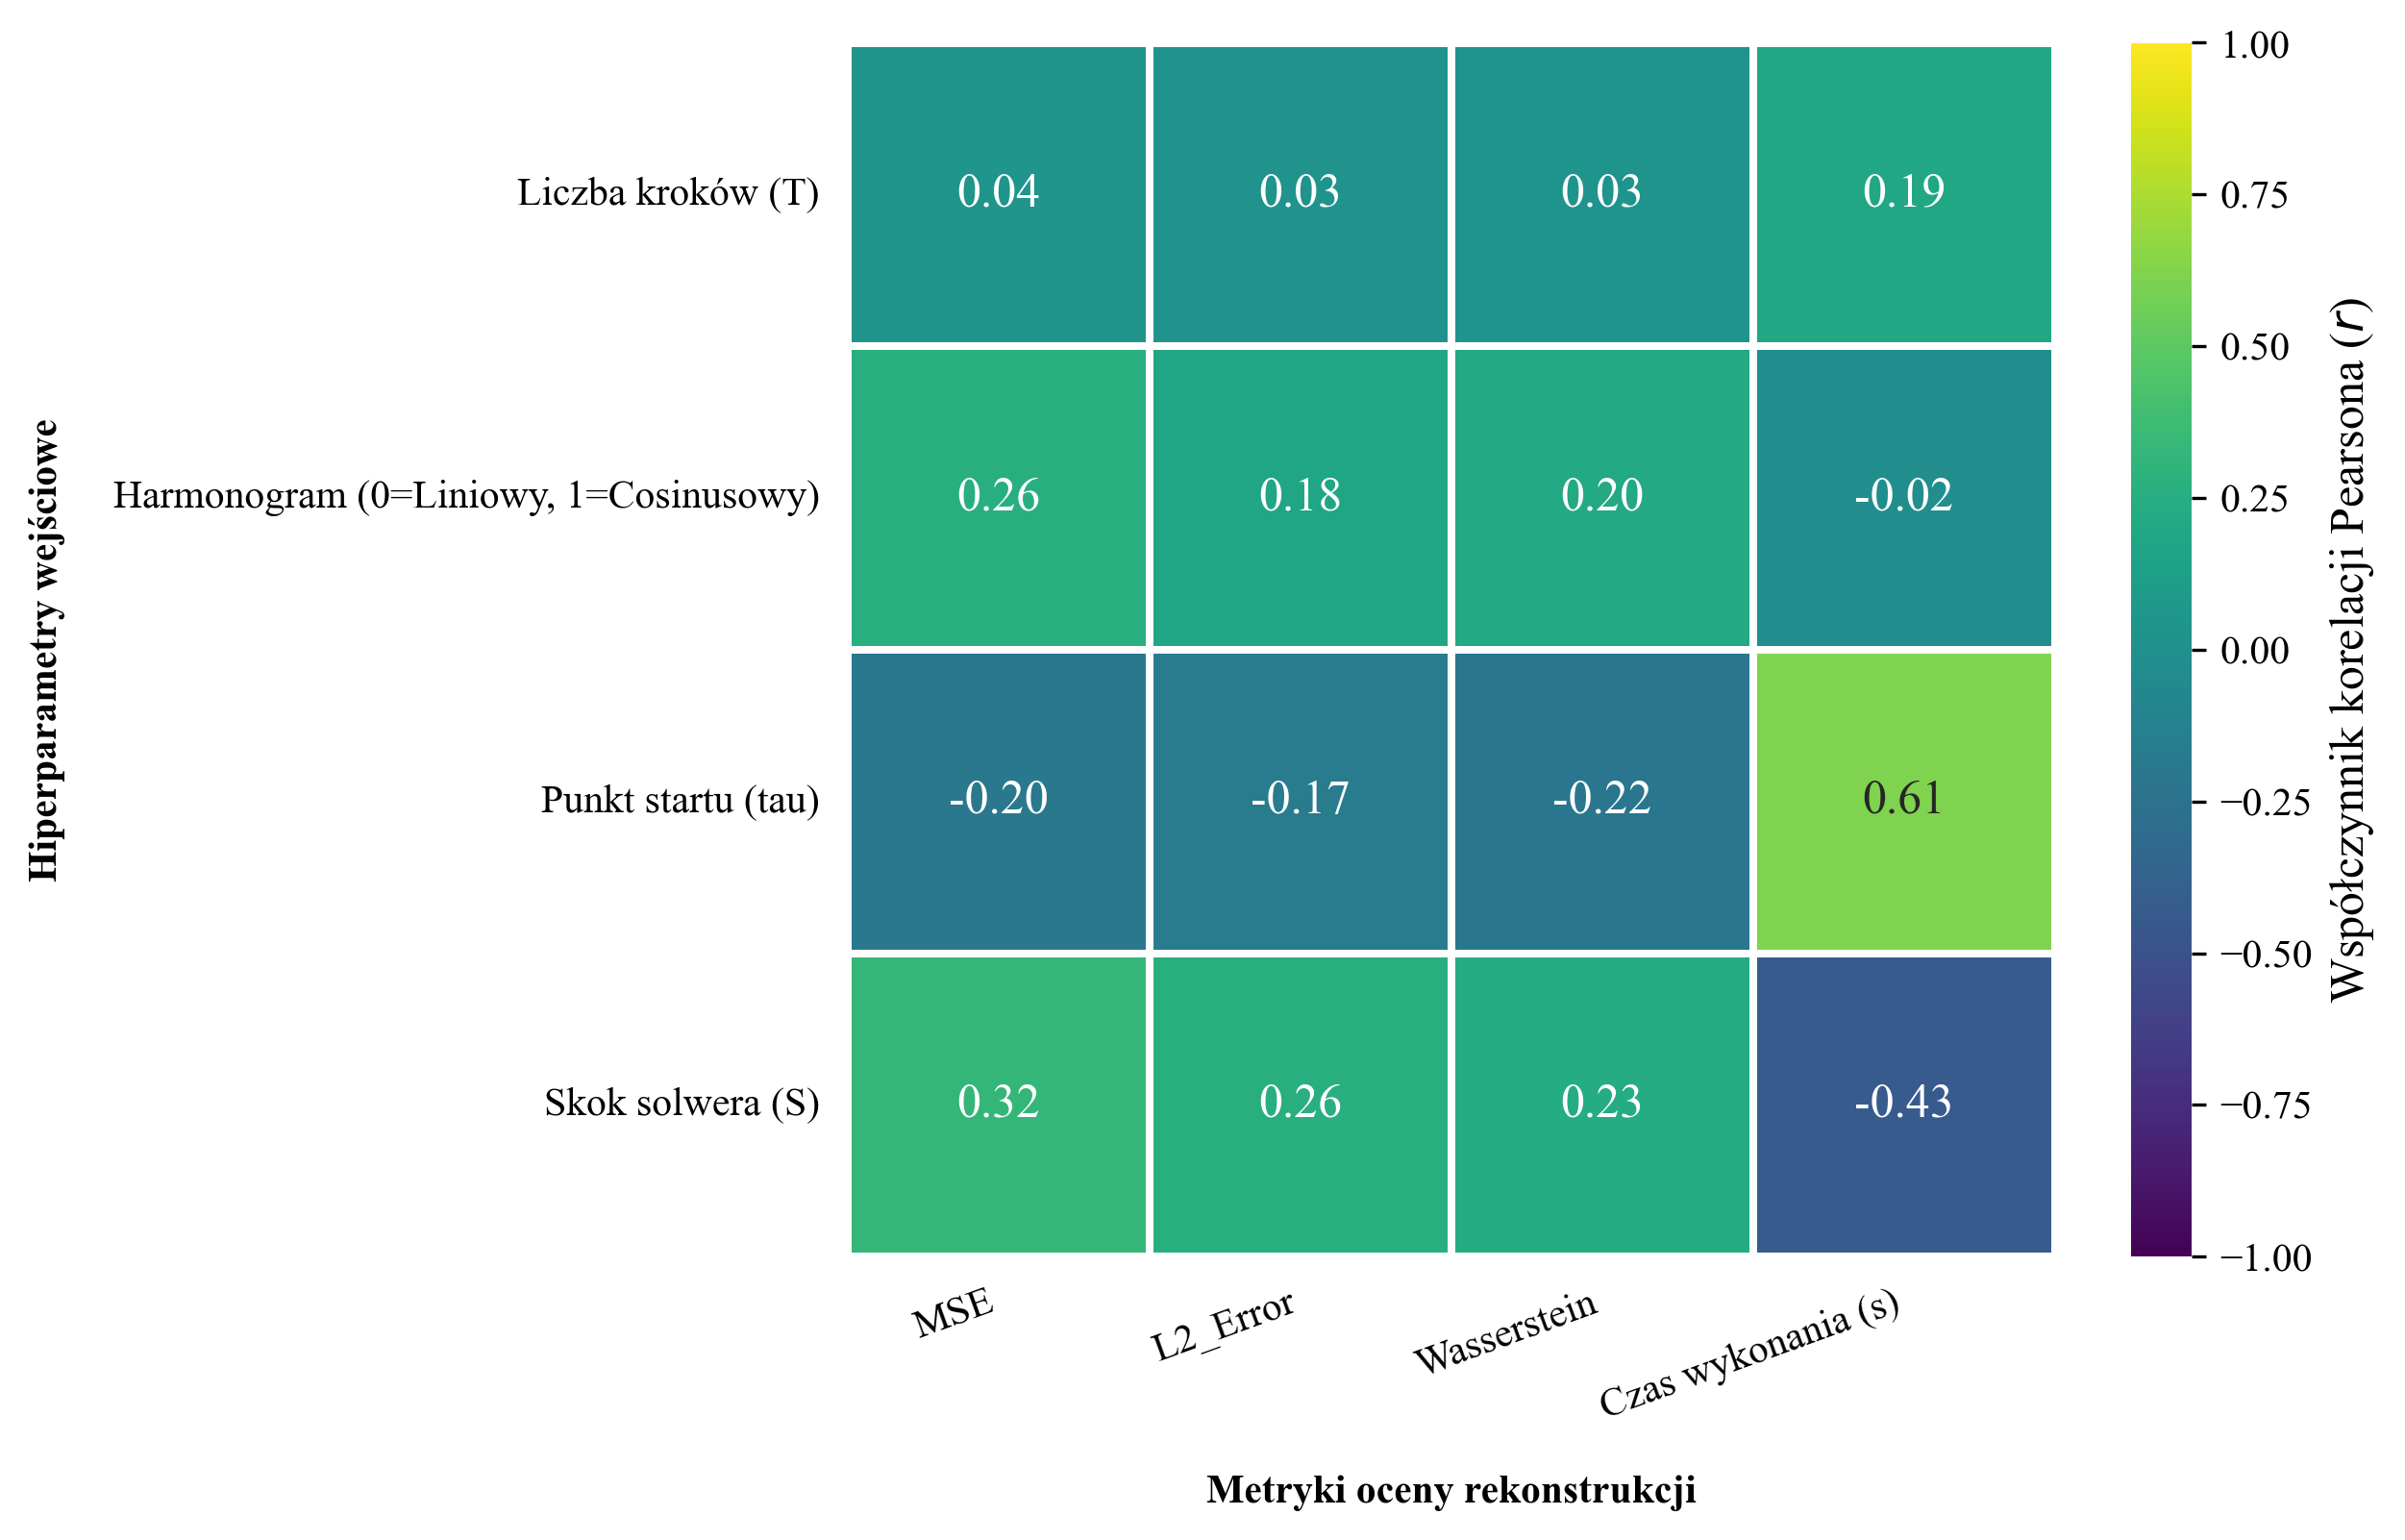

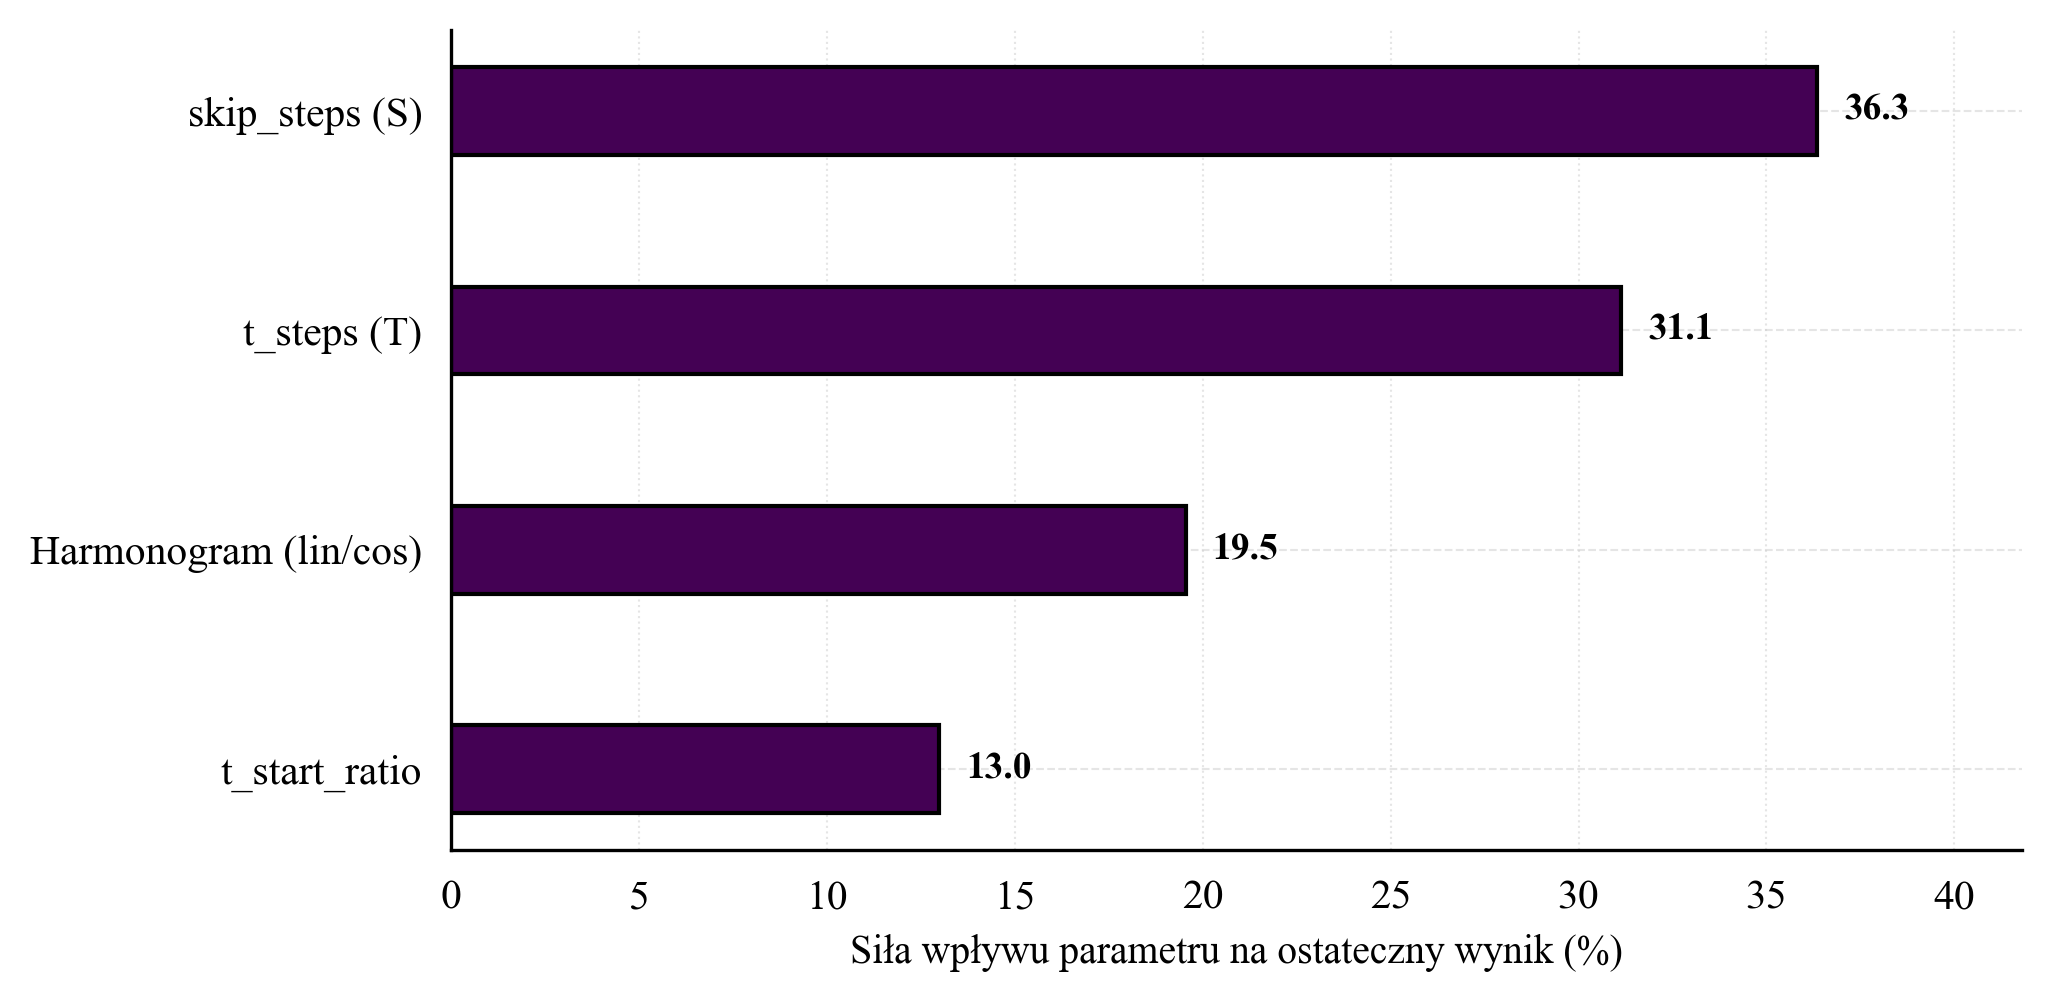


=== STATYSTYKI BŁĘDU DLA PARAMETRU t_start_ratio ===
 Wartość t_start_ratio  Średni błąd (%)  Mediana (%)  Kwartyl 1 (25%)  Kwartyl 3 (75%)
                  0.20          18.2437      10.8457           4.0691          22.9761
                  0.35           5.2193       1.3036           1.1772           5.9336
                  0.50           6.2164       2.5223           1.2430           5.8808
                  0.70           5.1096       3.0337           1.3365           5.7885

=== STATYSTYKI BŁĘDU DLA SKOKU SOLWERA (skip_steps) ===
 Wartość skip_steps (S)  Średni błąd (%)  Mediana (%)  Kwartyl 1 (25%)  Kwartyl 3 (75%)
                      1        13.348400       6.4113           3.1653          18.4598
                      2         9.602900       5.5785           3.3582           8.6979
                      5        26.477301      17.4618           6.0603          32.8337

=== STATYSTYKI BŁĘDU DLA HARMONOGRAMU SZUMU ===
Wartość Harmonogram  Średni błąd (%)  Mediana (%)  Kw

,Funkcja,Architektura,T,Schedule,Ratio,Skip steps,L2_Error,Czas
0,1_OVER_X,UNet_C256_5e-4,80,linear,0.700000,5.000000,5.61e+00,0.01s
1,ABS,Conv1D_C128_1e-3,80,linear,0.200000,1.000000,3.55e+00,0.00s
2,CHIRP,UNet_C64_1e-4,80,linear,0.200000,1.000000,2.95e+00,0.00s
3,DAMPED_OSCILLATOR,Conv1D_C128_5e-4,100,linear,0.200000,1.000000,5.13e+00,0.01s
4,EXP,UNet_C64_1e-4,80,linear,0.700000,5.000000,1.17e+00,0.00s
5,LOG10,UNet_C64_1e-4,80,linear,0.200000,5.000000,2.72e+00,0.00s
6,MIXED_FREQ,Conv1D_C128_1e-3,80,linear,0.200000,1.000000,3.24e+00,0.00s
7,SINC,Conv1D_C128_1e-3,80,linear,0.200000,5.000000,2.51e+00,0.00s
8,SQUARE_WAVE,Conv1D_C128_1e-3,100,linear,0.350000,1.000000,1.06e+00,0.01s
9,STEP,Conv1D_C128_5e-4,80,linear,0.350000,1.000000,1.03e+00,0.00s



| RAPORT 2: GLOBALNY RANKING PARAMETRÓW |

TOP 5 GLOBALNYCH KONFIGURACJI:


,T,Schedule,Ratio,Skip steps,Sredni_Blad_L2,Mediana_Bledu_L2,Sredni_Czas_Inferencji,Liczba_Sukcesow
0,120,linear,0.350000,1.000000,2.73e+00,1.18e+00,0.01s,3
1,80,linear,0.350000,1.000000,3.08e+00,1.19e+00,0.01s,11
2,100,linear,0.350000,1.000000,2.08e+00,1.23e+00,0.01s,11
3,80,linear,0.700000,5.000000,3.03e+00,1.23e+00,0.00s,5
4,100,linear,0.500000,2.000000,1.26e+00,1.26e+00,0.01s,2


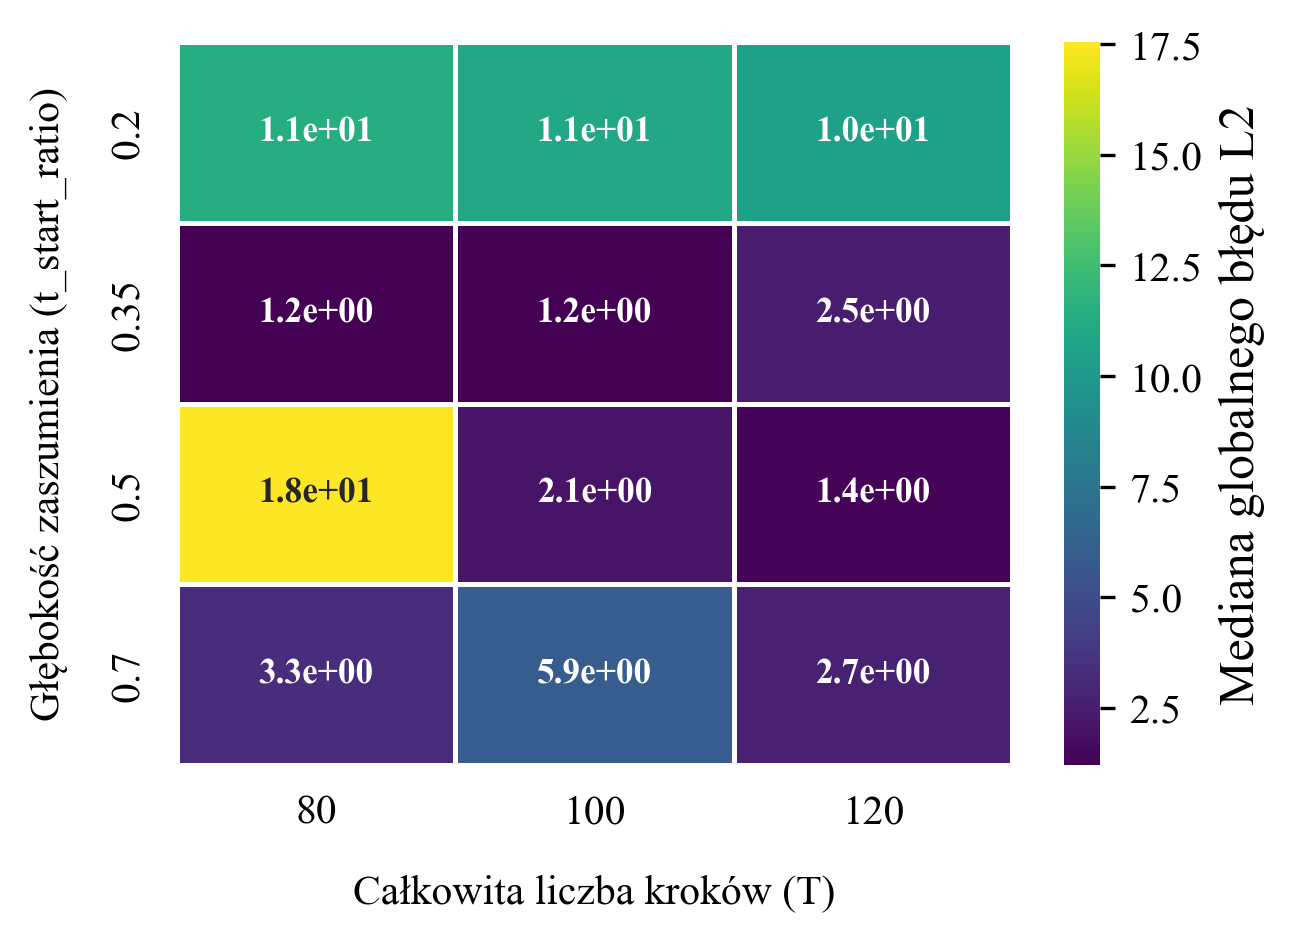

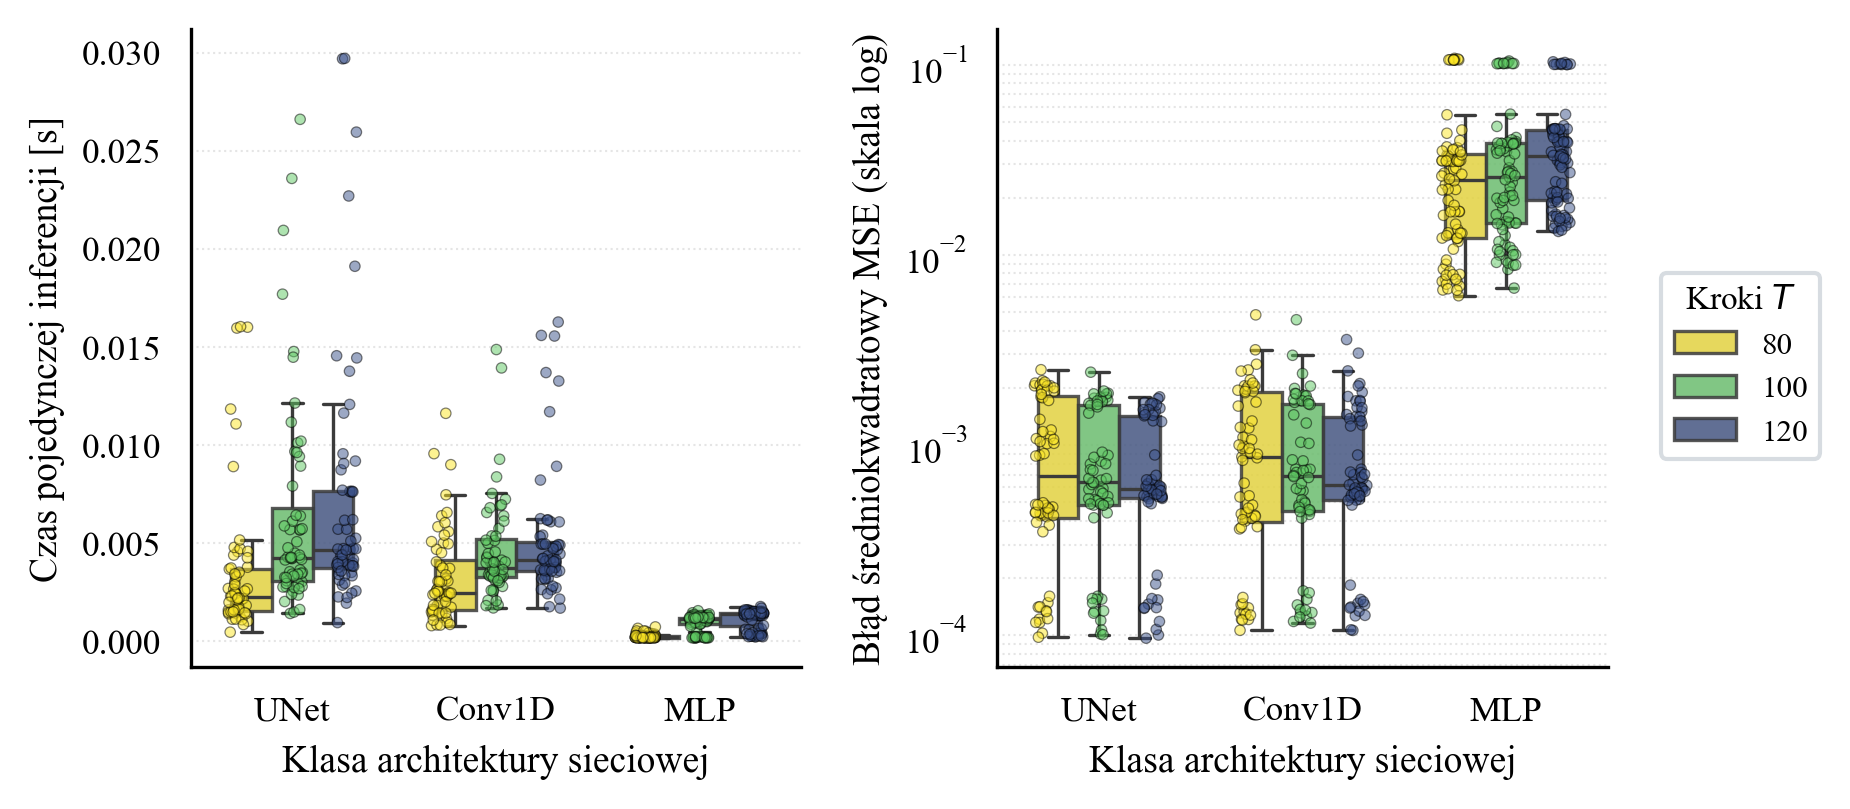

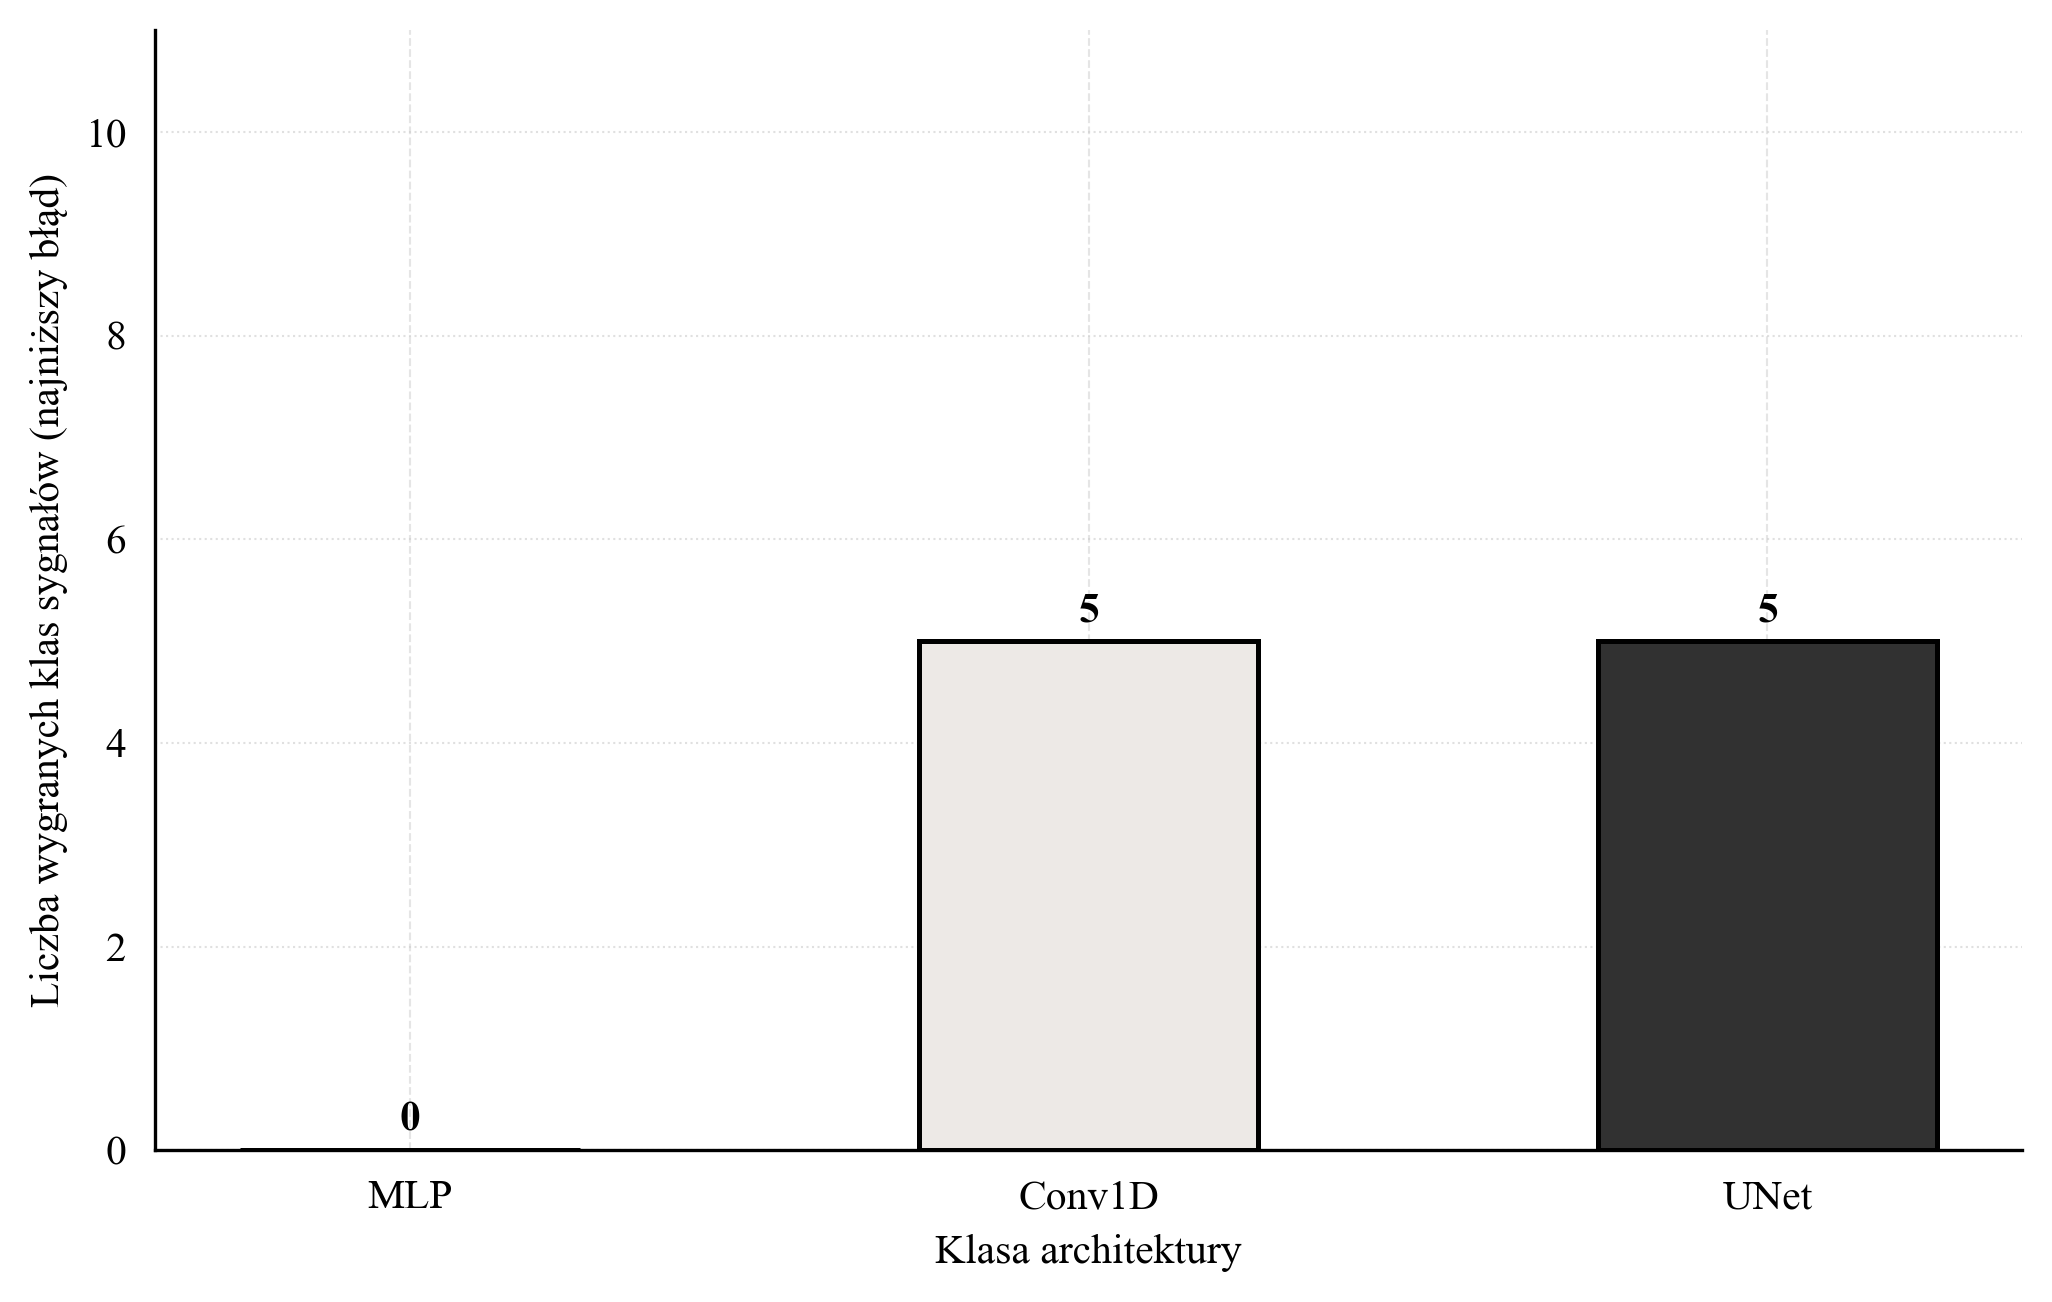


TOP 3 NAJLEPSZE GLOBALNIE KONFIGURACJE:


,Architektura,T,Schedule,Ratio,Mean_MSE,Median_MSE,Mean_L2,Mean_Wasserstein,Mean_Pearson,Mean_Inference_Time
0,Conv1D_C128_1e-3,80,linear,0.350000,3.07e-04,3.68e-04,3.0379,0.0093,0.0000,0.0040s
1,Conv1D_C128_5e-4,80,linear,0.350000,3.14e-04,3.84e-04,3.0973,0.0094,0.0000,0.0032s
2,UNet_C64_1e-4,80,linear,0.350000,3.20e-04,3.95e-04,3.1389,0.0095,0.0000,0.0026s



TOP 3 NAJGORSZE GLOBALNIE KONFIGURACJE:


,Architektura,T,Schedule,Ratio,Mean_MSE,Median_MSE,Mean_L2,Mean_Wasserstein,Mean_Pearson,Mean_Inference_Time
57,MLP_C32_1e-4,120,cosine,0.350000,1.01e-01,1.01e-01,62.5356,0.1453,0.0000,0.0004s
58,MLP_C32_1e-4,100,cosine,0.350000,1.02e-01,1.02e-01,62.8144,0.1447,0.0000,0.0002s
59,MLP_C32_1e-4,80,cosine,0.350000,1.07e-01,1.06e-01,64.2051,0.1495,0.0000,0.0003s


In [7]:
#ANALIZA GLOBALNA (MAKRO) 
print("\n1.Generowanie globalnych raportów i statystyk systemowych (MAKRO)...")

vis.generate_metrics_report(test_functions, architectures_config)

vis.plot_global_correlation_sensitivity(df_sensitivity)

vis.param_importance(df_sensitivity)

vis.single_params_impact(df_sensitivity)

vis.config_ranking(df_sensitivity)

vis.generate_global_sdedit_report(test_functions, architectures_config)

vis.generate_quality_time_plots(test_functions, architectures_config)

vis.plot_architecture_dominance_matrix(test_functions, architectures_config)

best_cfg, worst_cfg = vis.generate_comprehensive_global_report(test_functions, architectures_config, runner)



 2.Generowanie wykresów interakcji hiperparametrów (MEZO)...


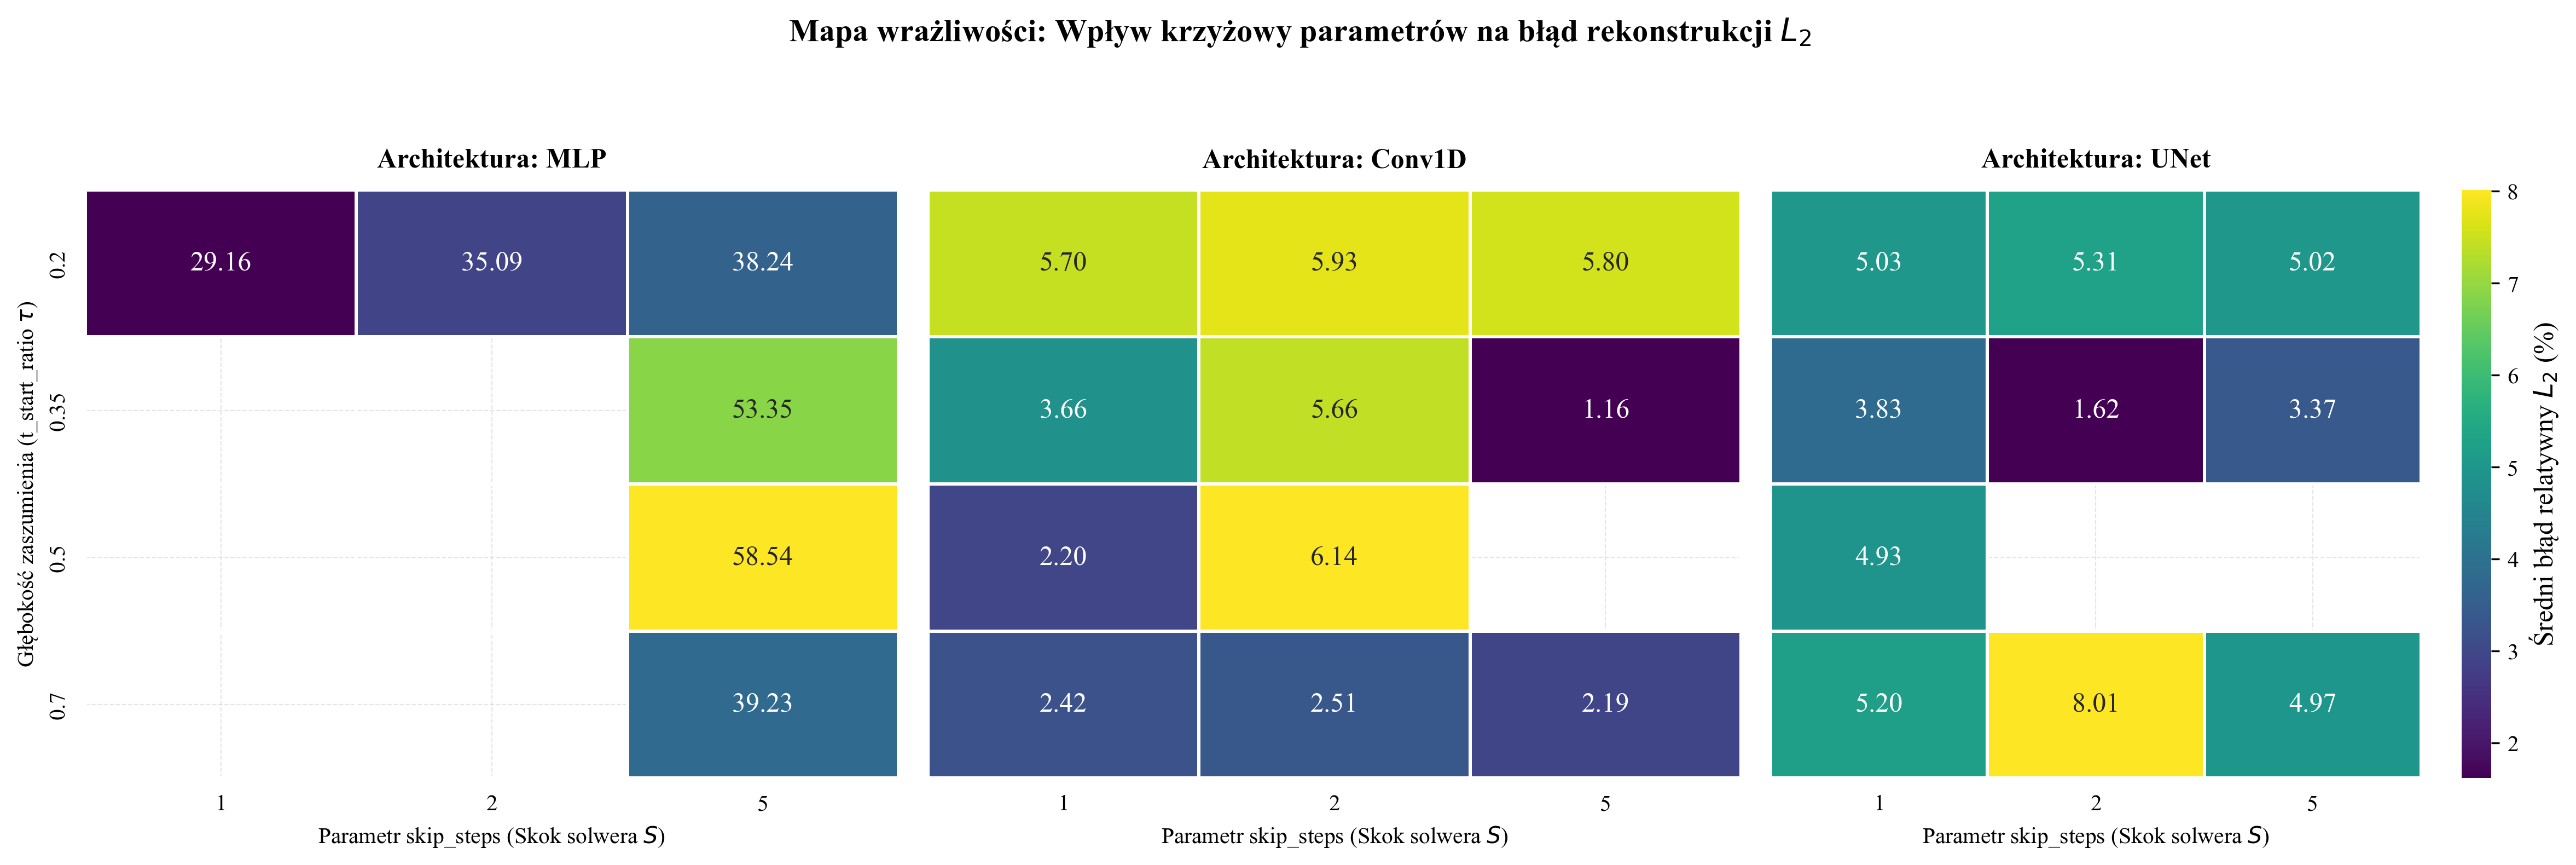

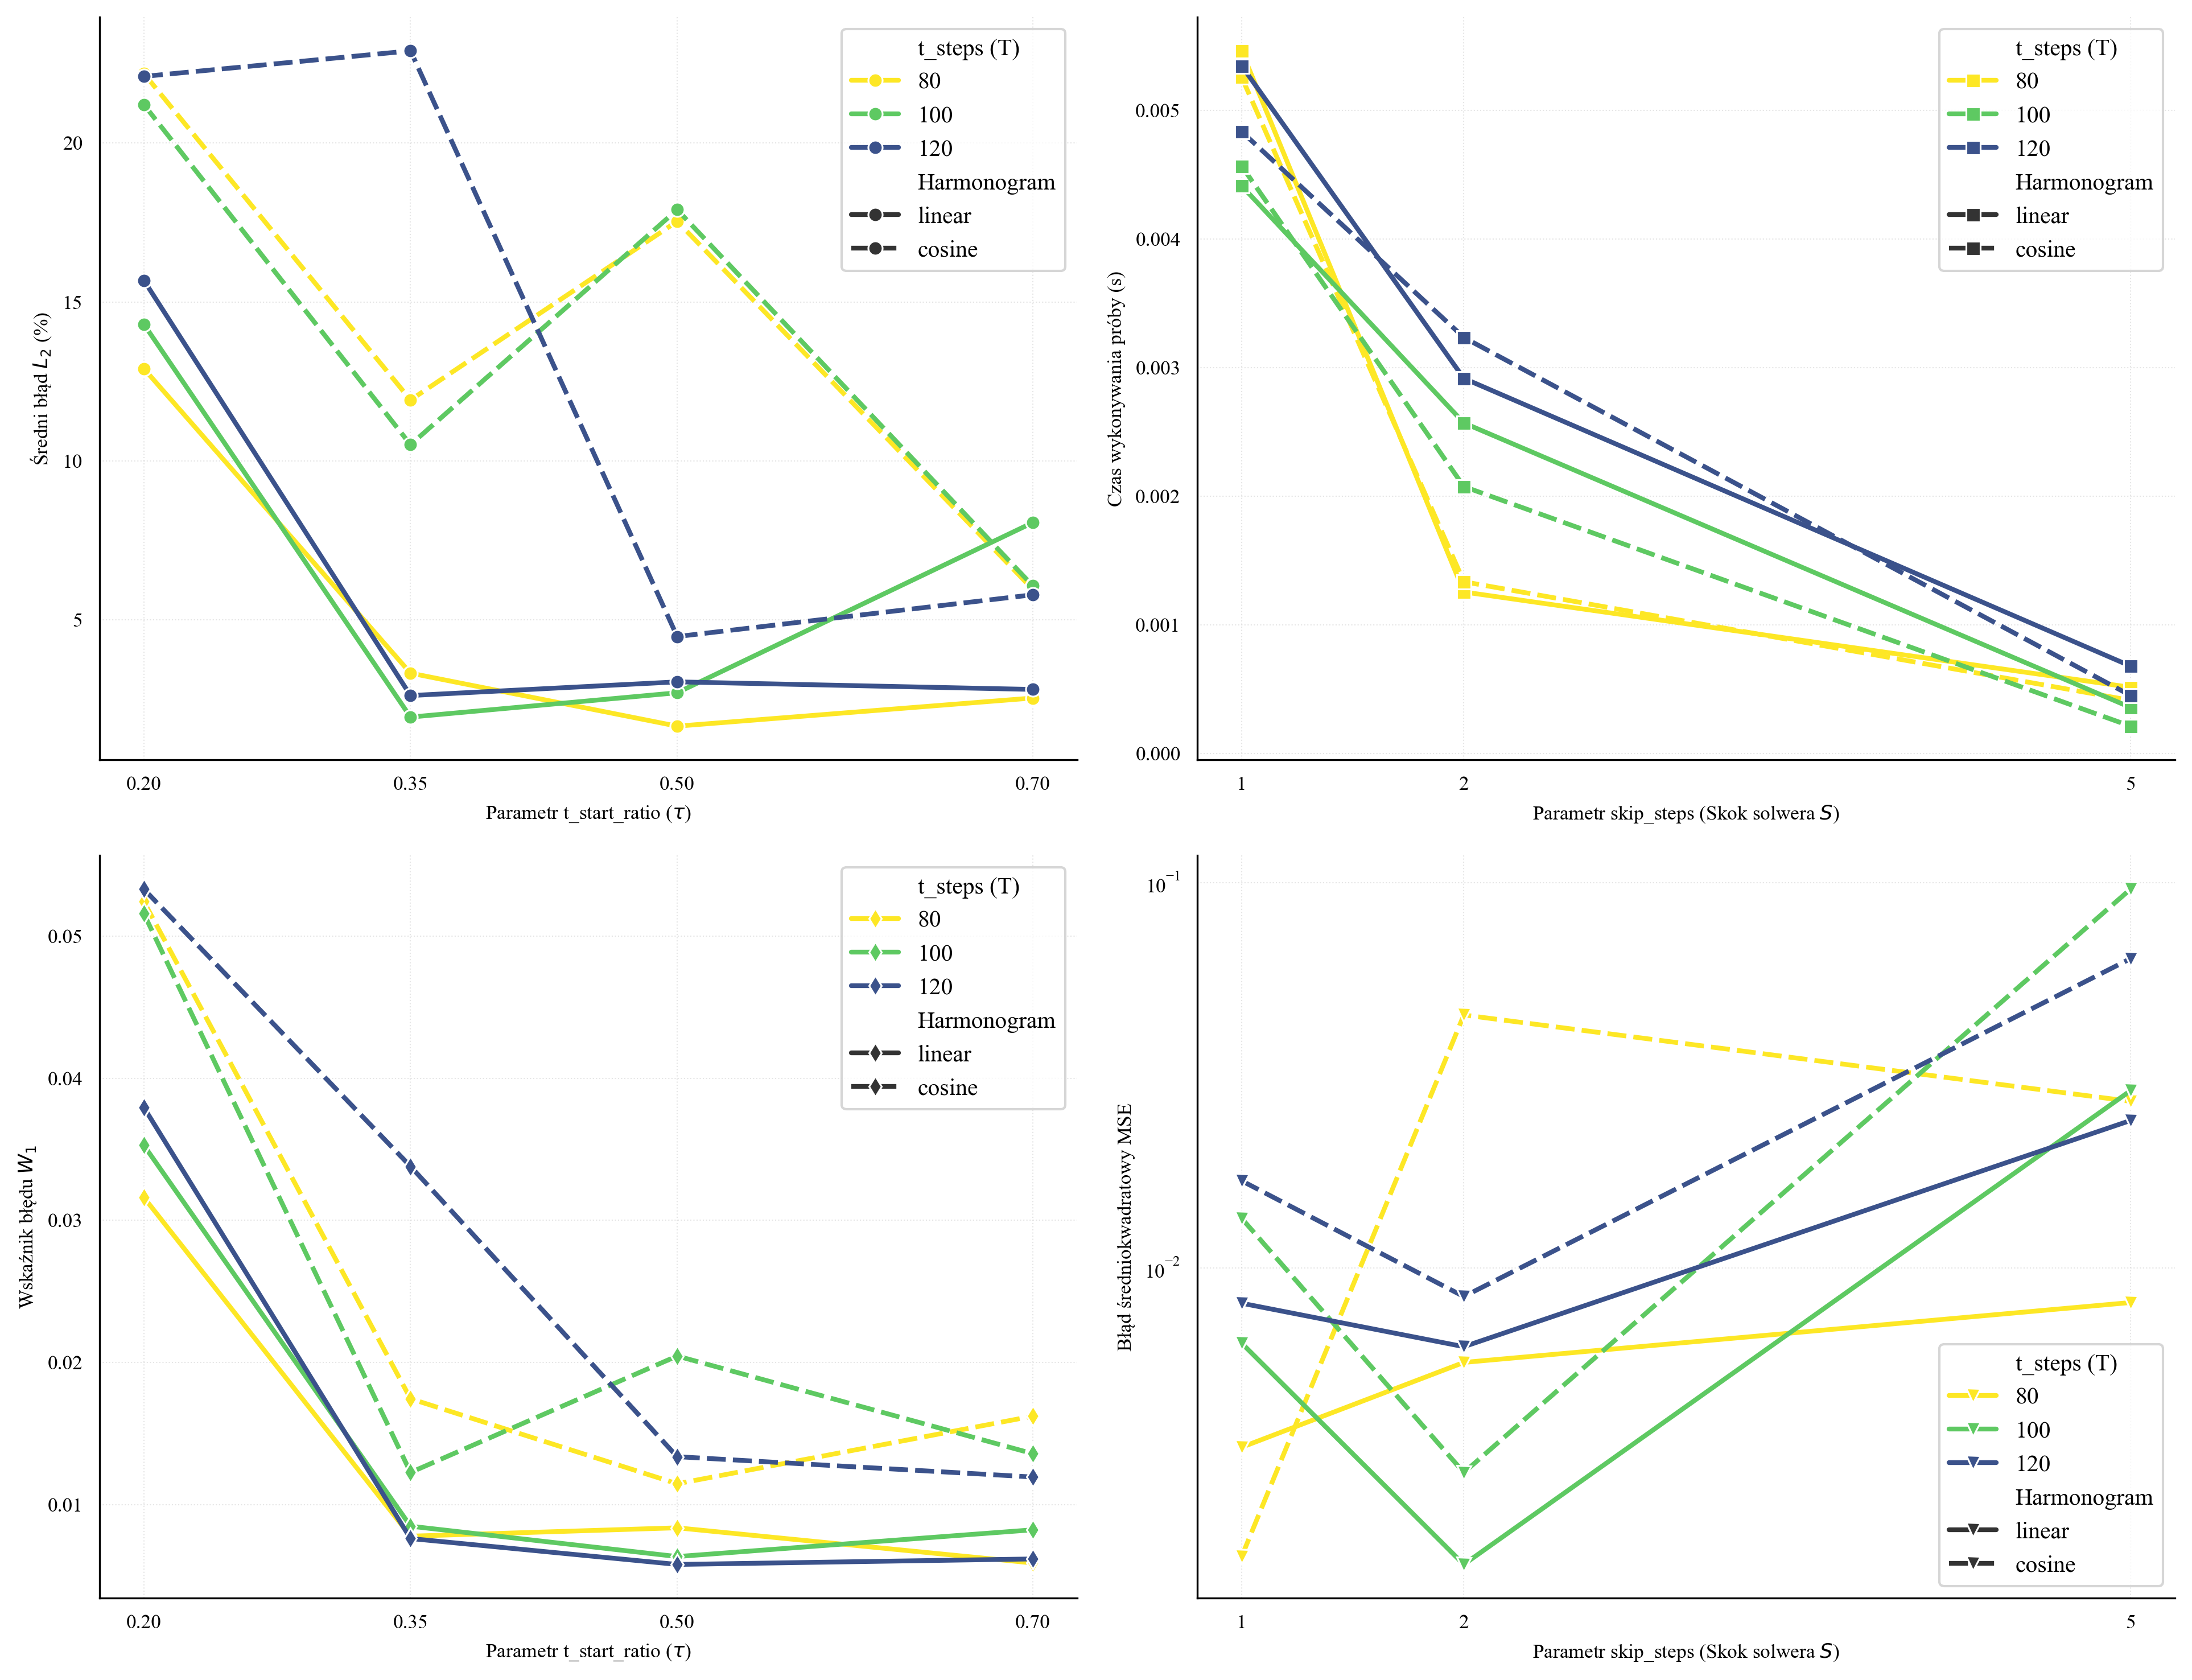

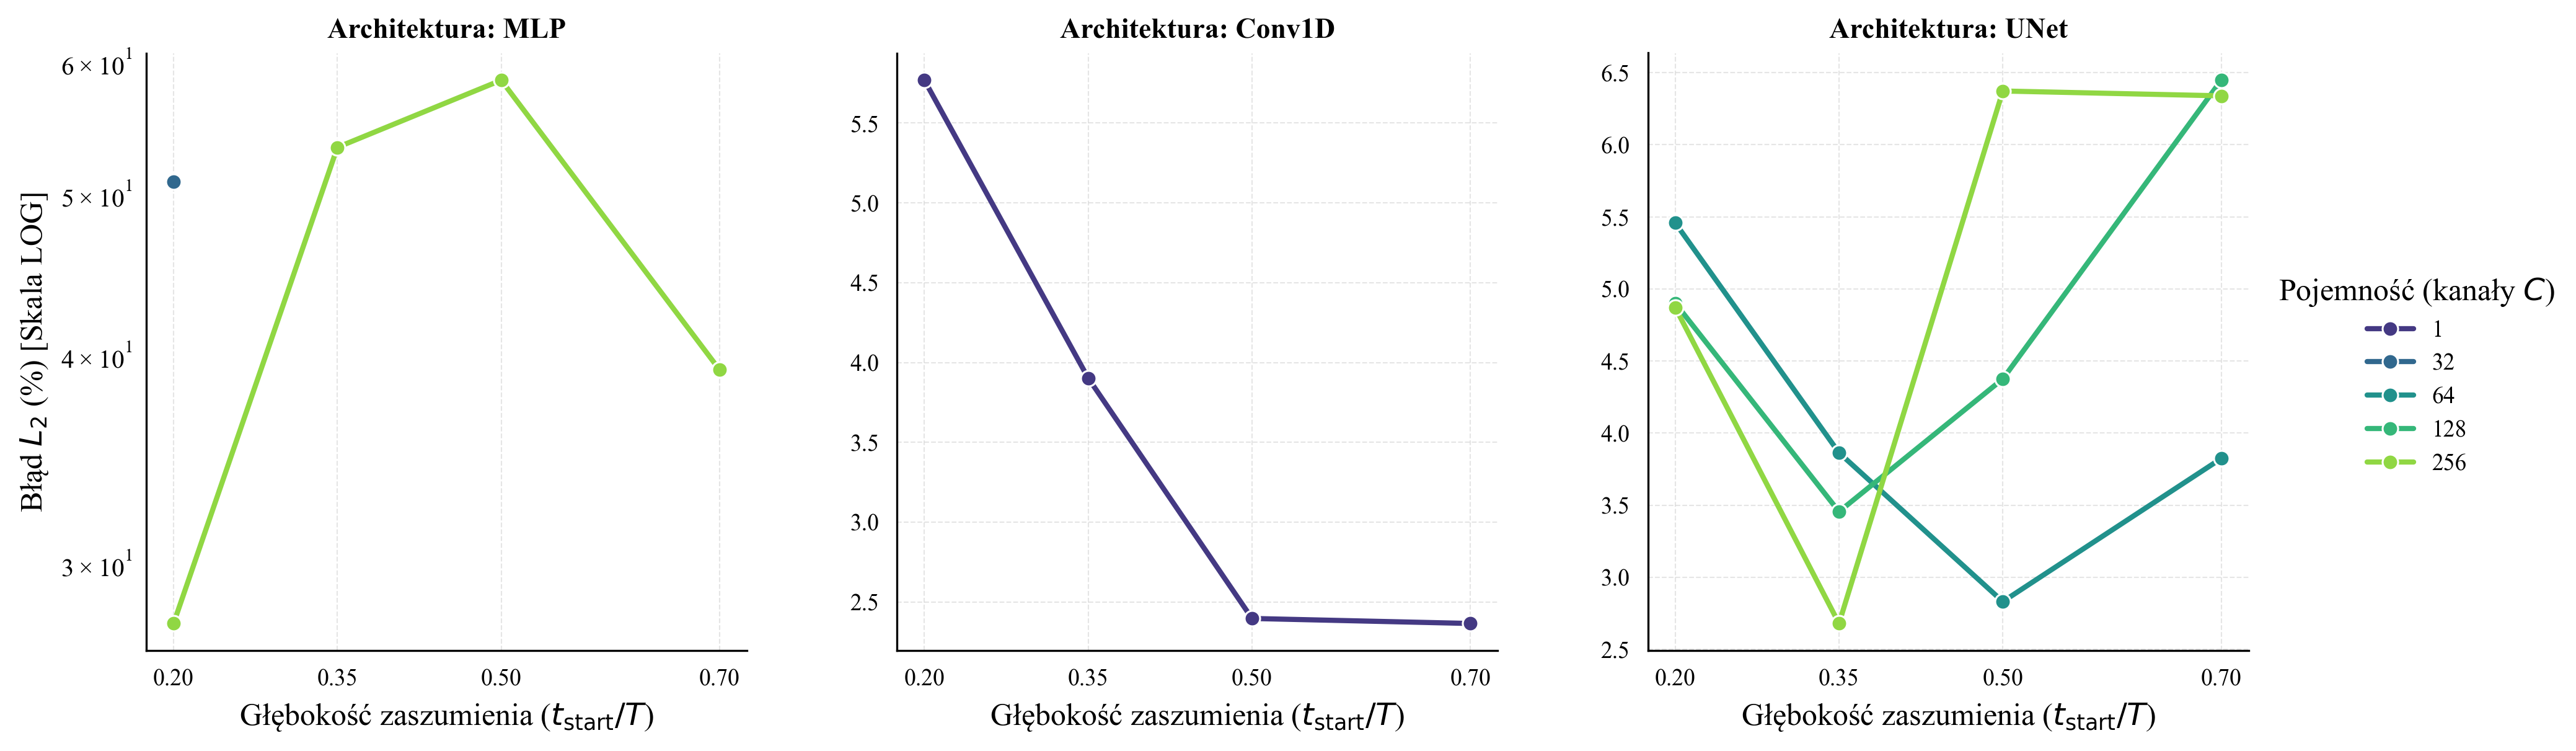

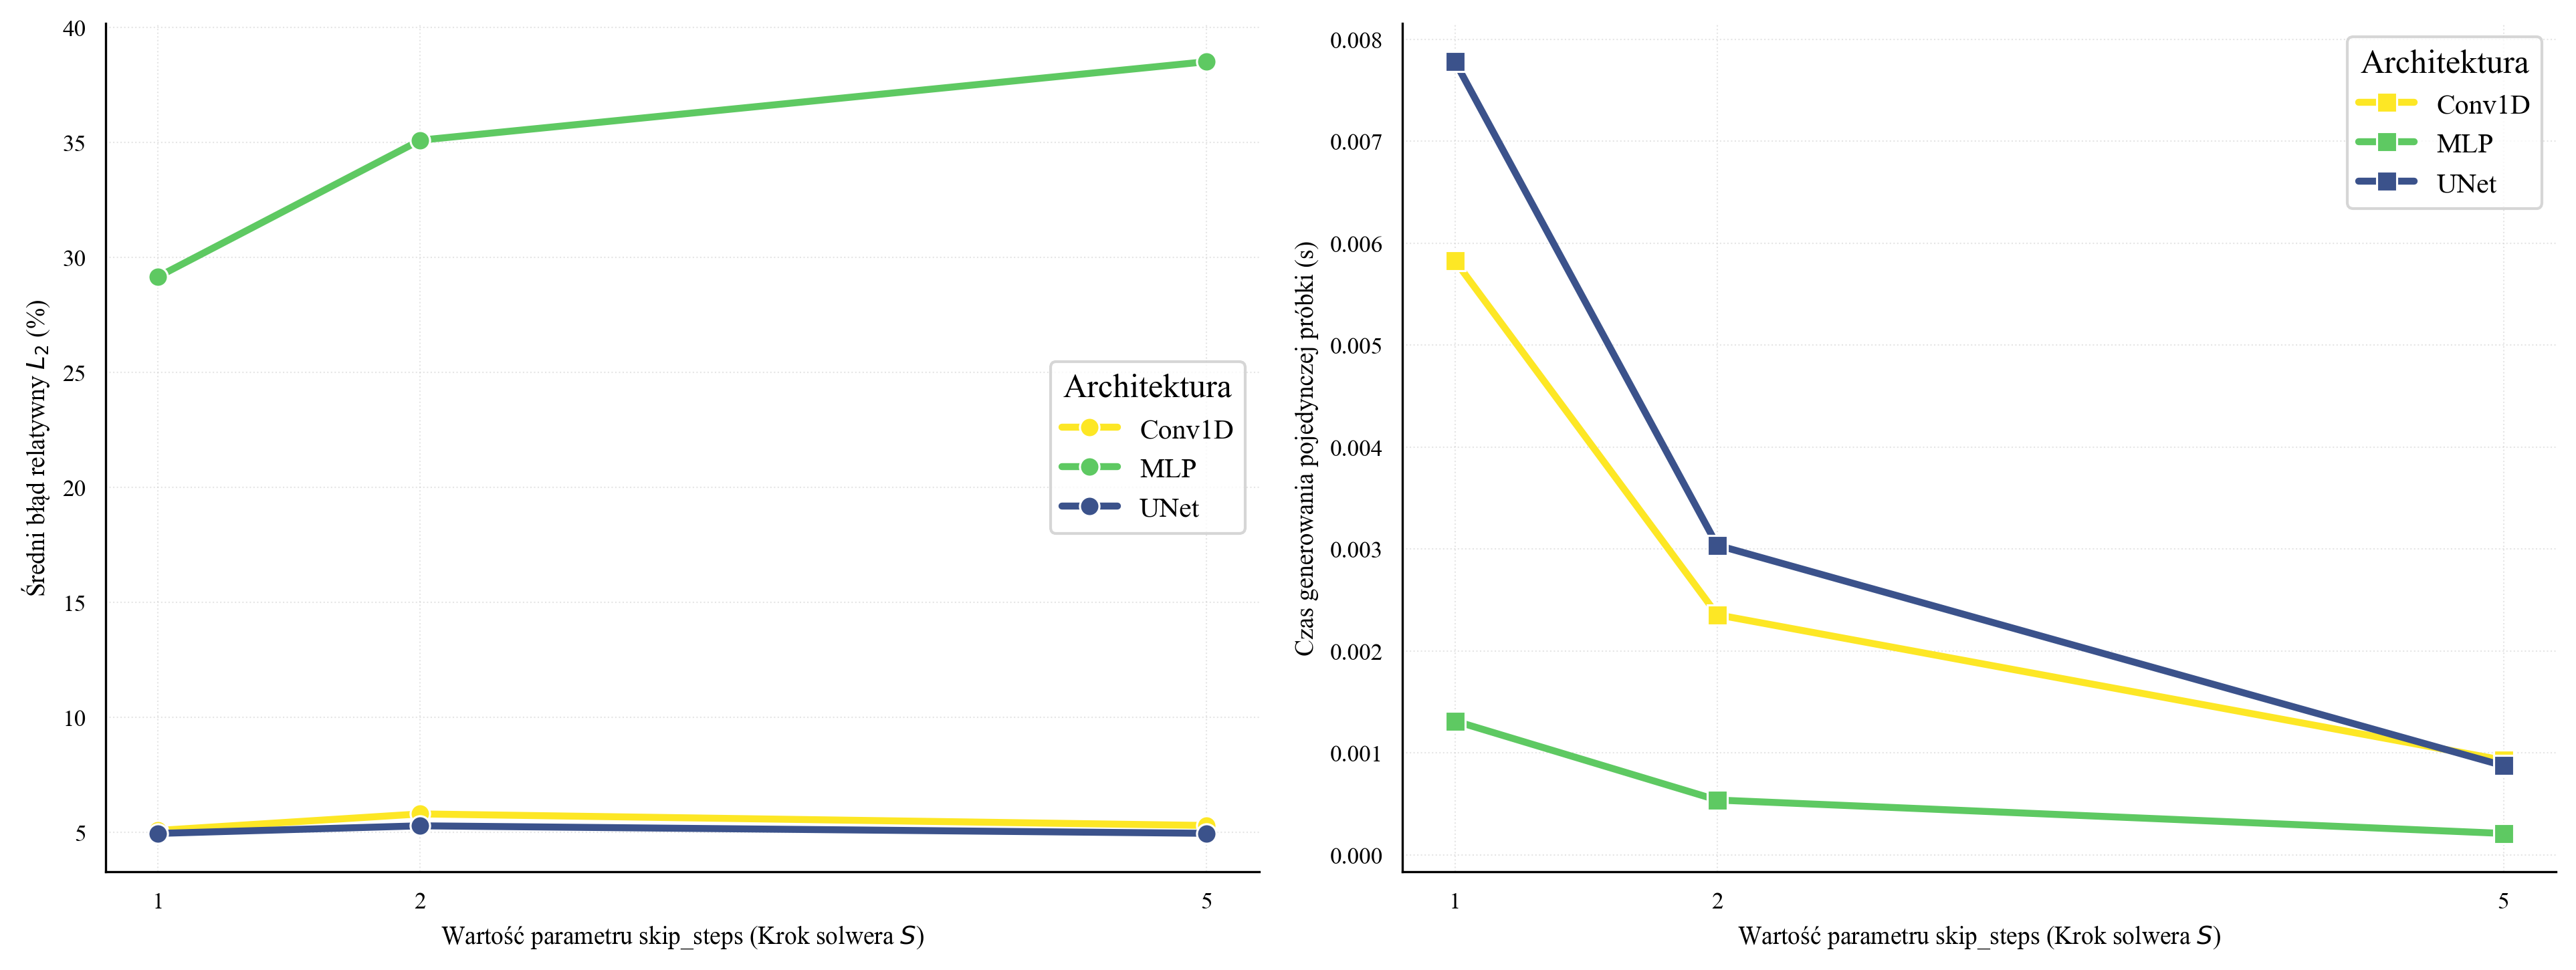

In [8]:
# INTERAKCJE PARAMETRÓW (MEZO)
print("\n 2.Generowanie wykresów interakcji hiperparametrów (MEZO)...")

vis.heatmap_params_impact(df_sensitivity)

vis.plot_deep_hyperparam_interactions(df_sensitivity)

vis.plot_sdedit_sensitivity_grid(test_functions, architectures_config)

vis.plot_sdedit_solver_tradeoff(test_functions, architectures_config)




3. Generowanie studiów przypadków dla wybranych funkcji (MIKRO)...


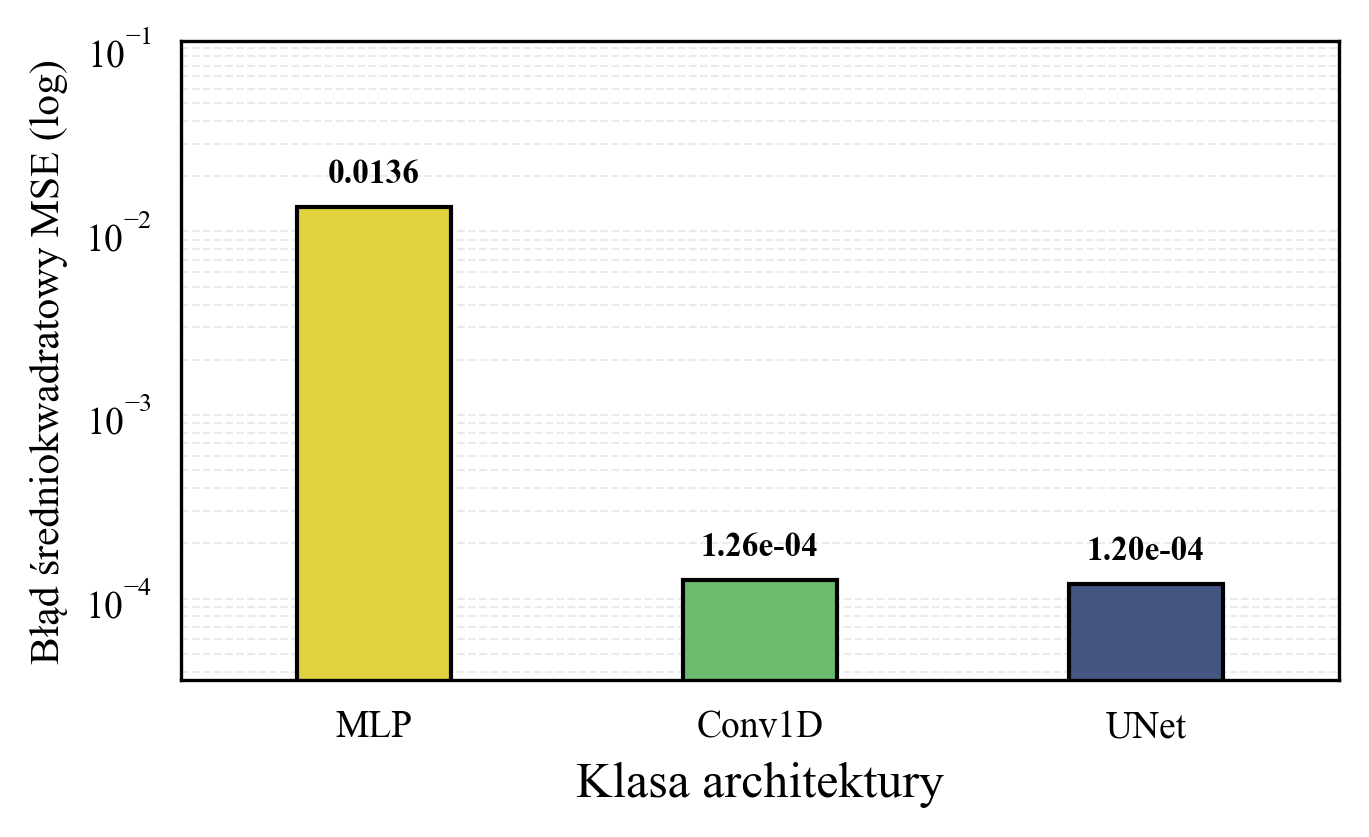

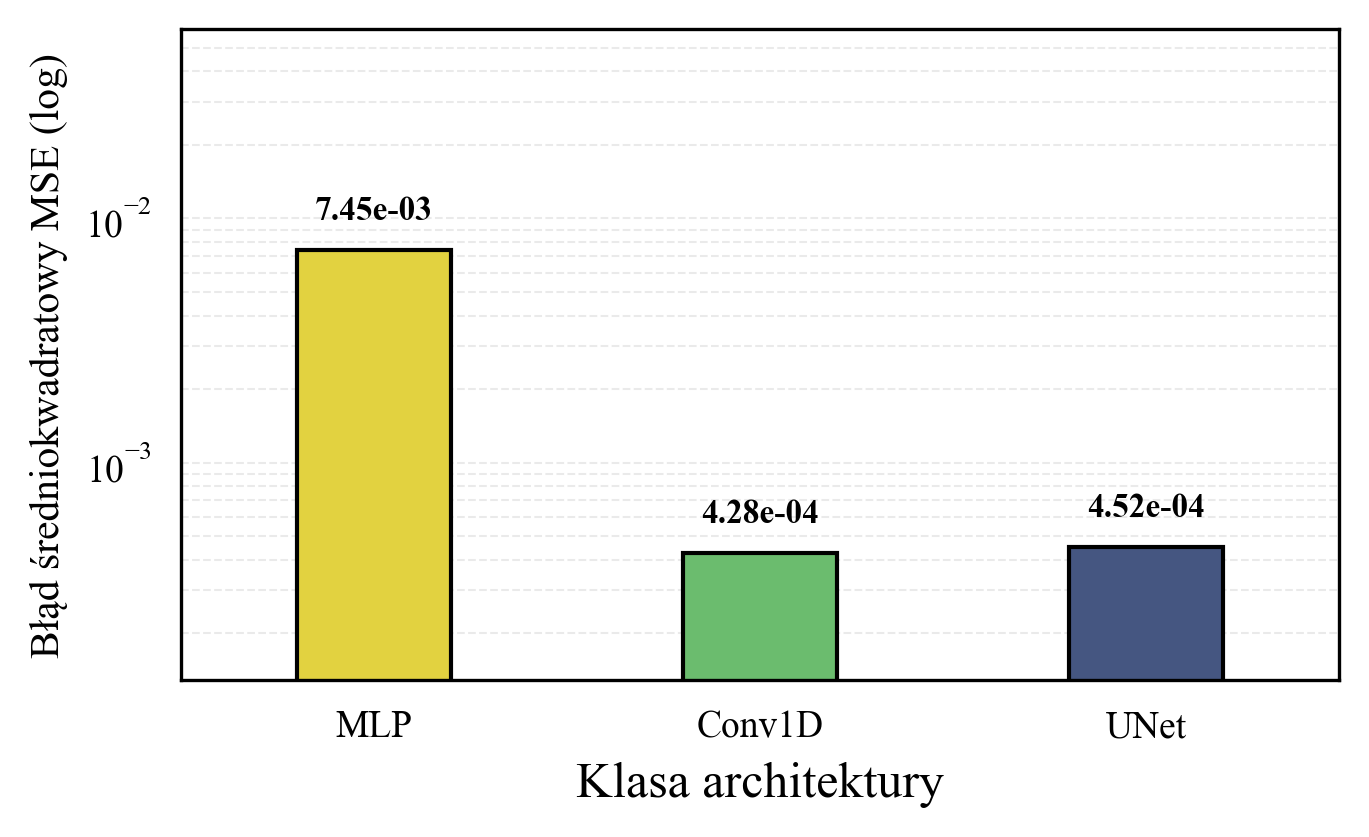

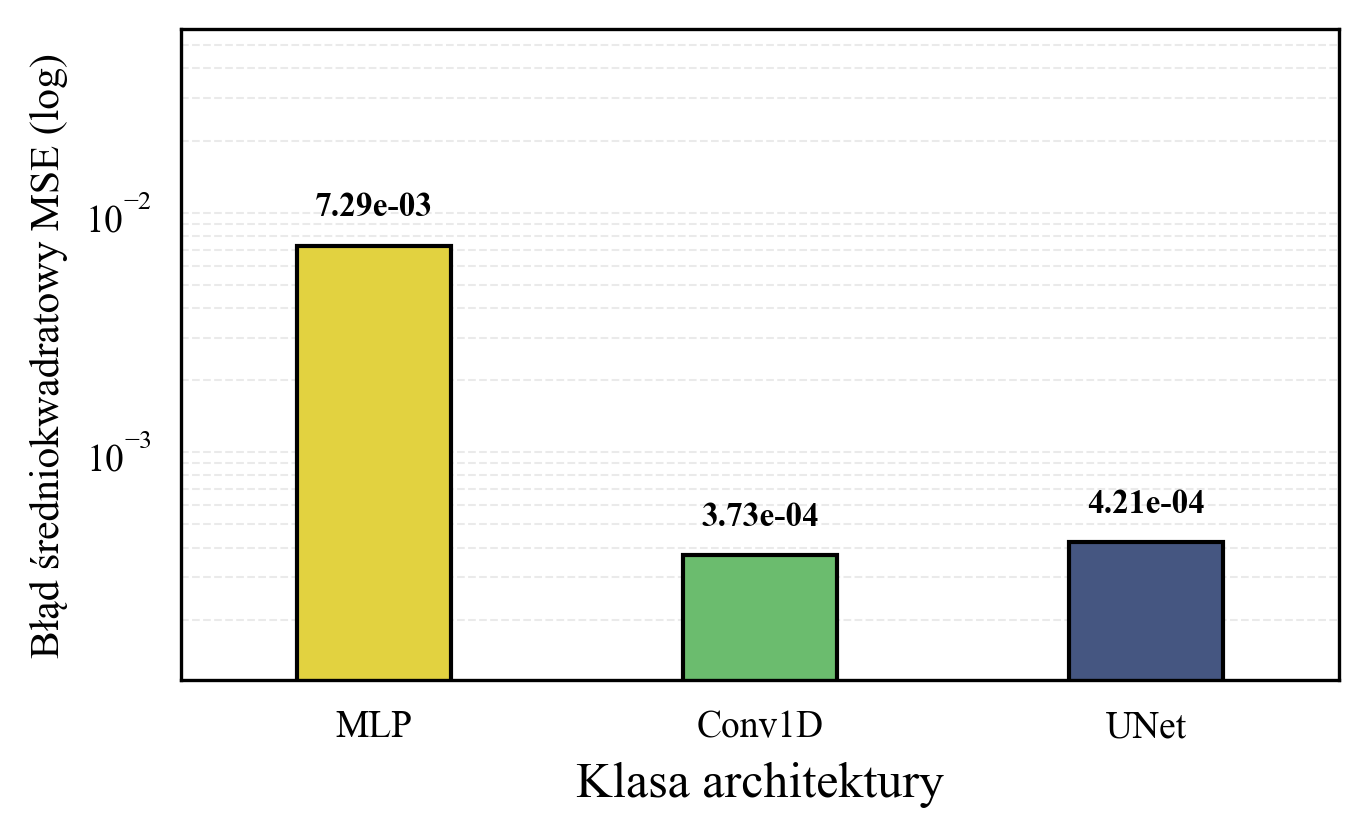

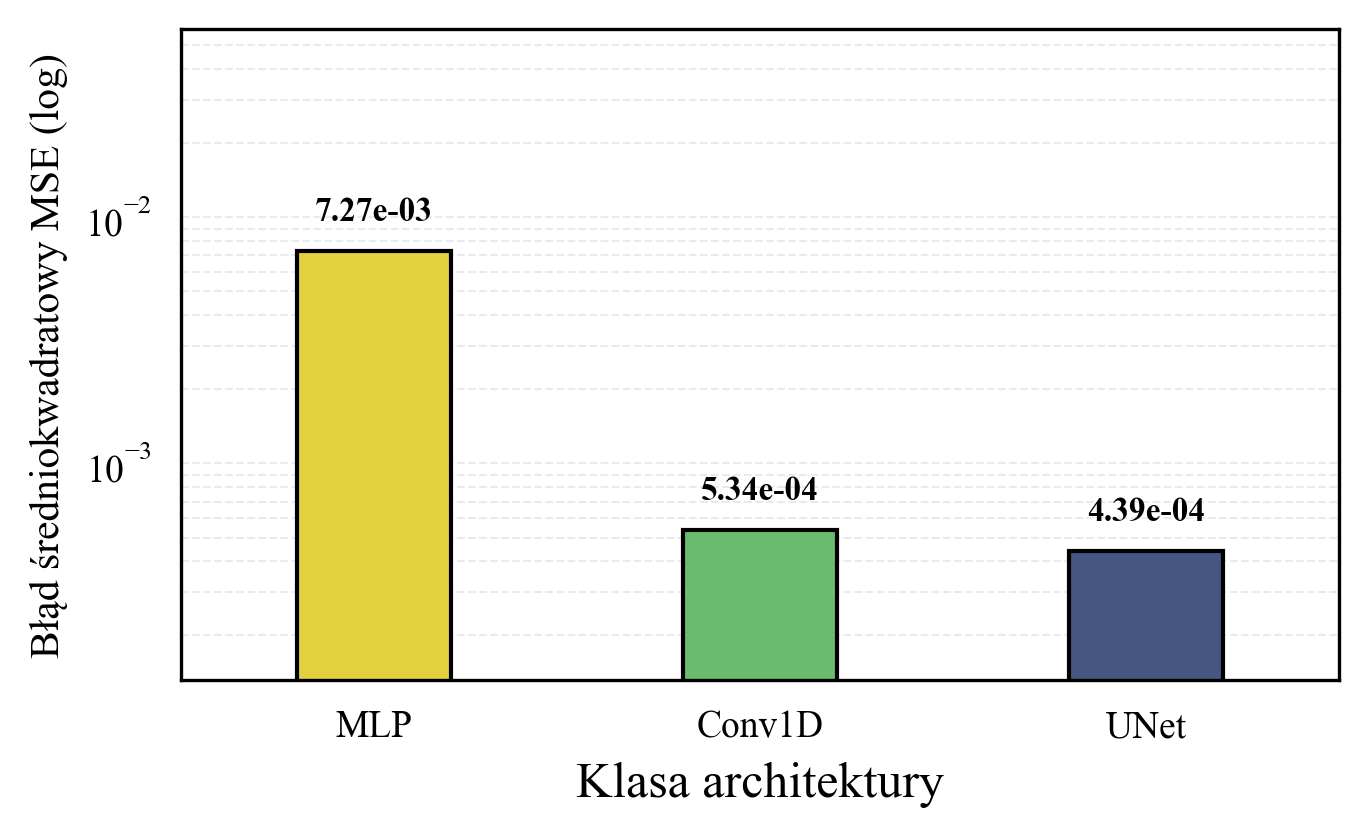

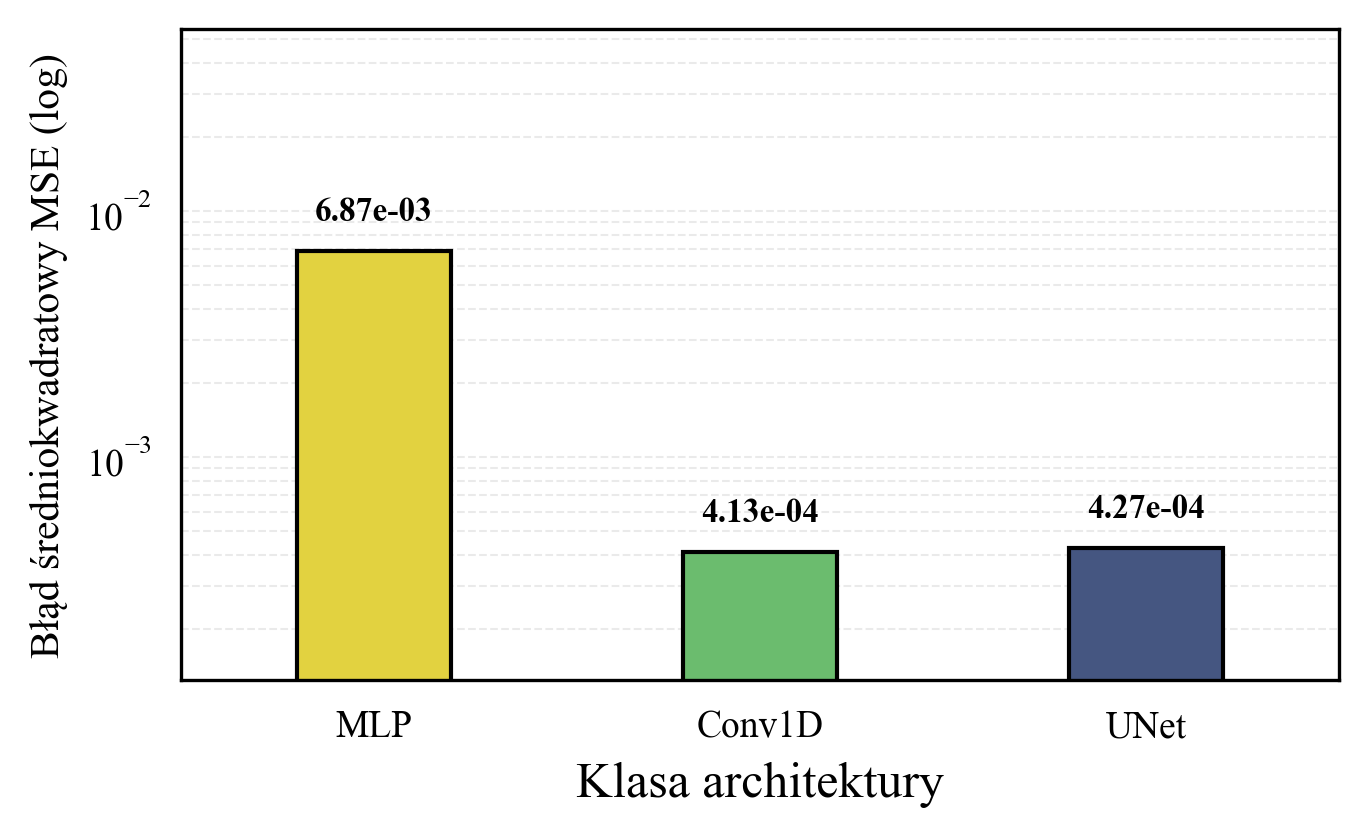

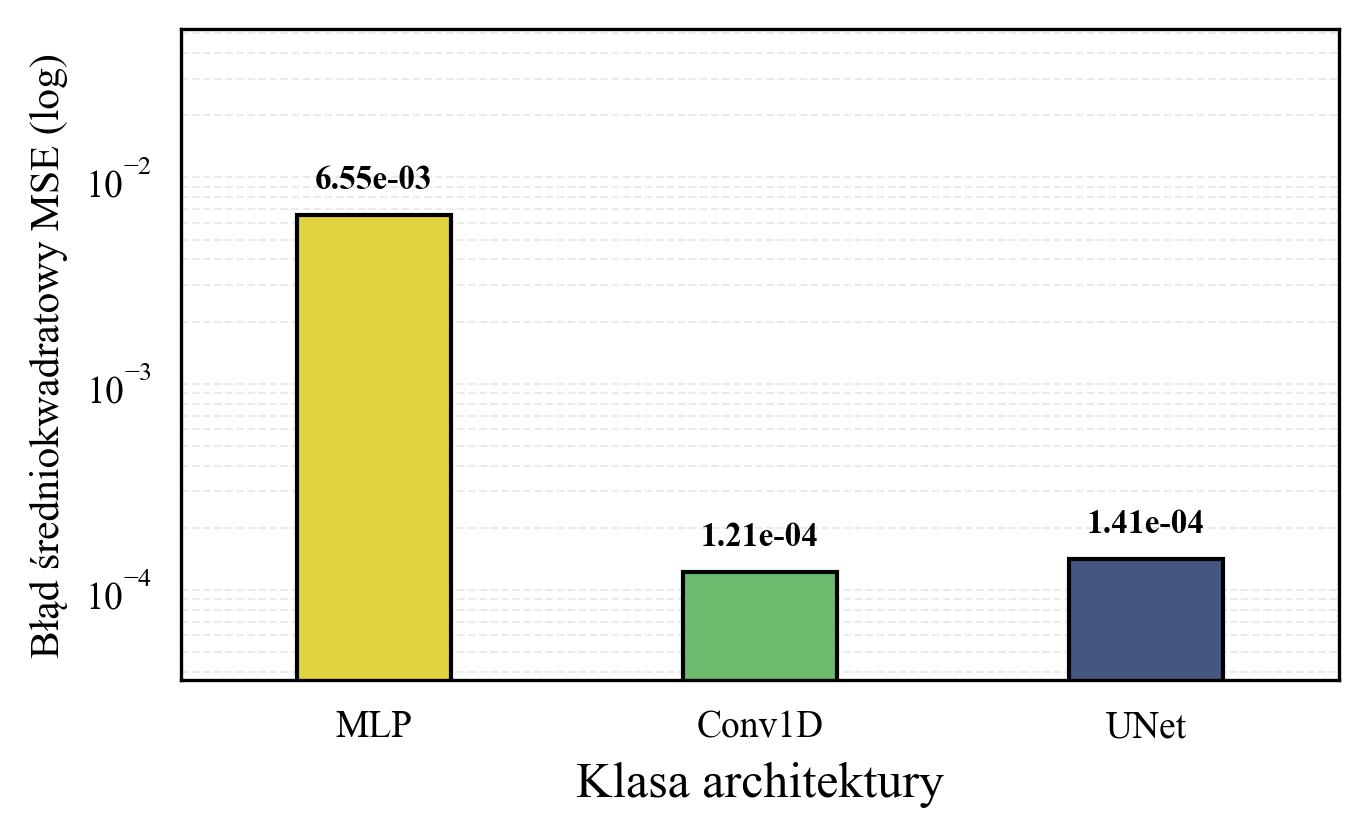

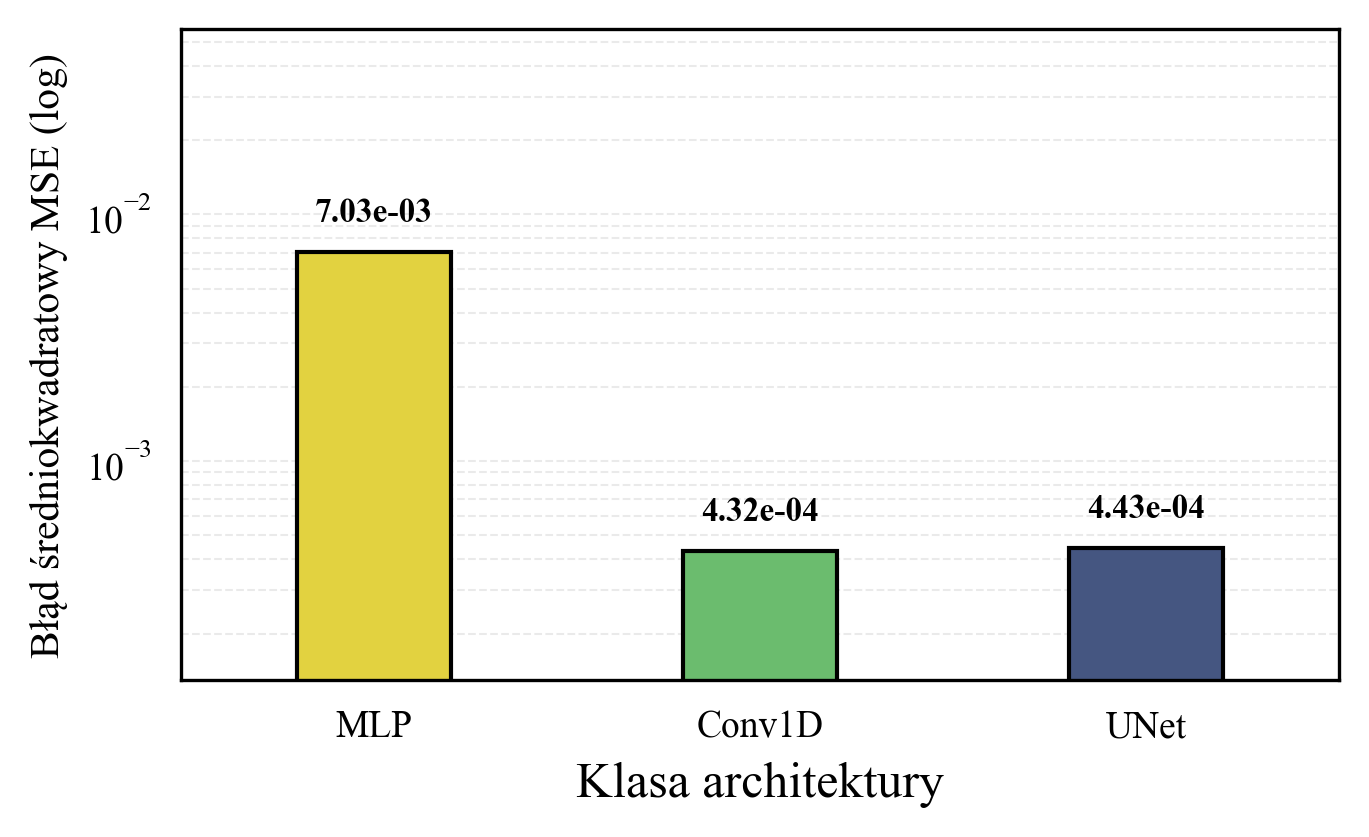

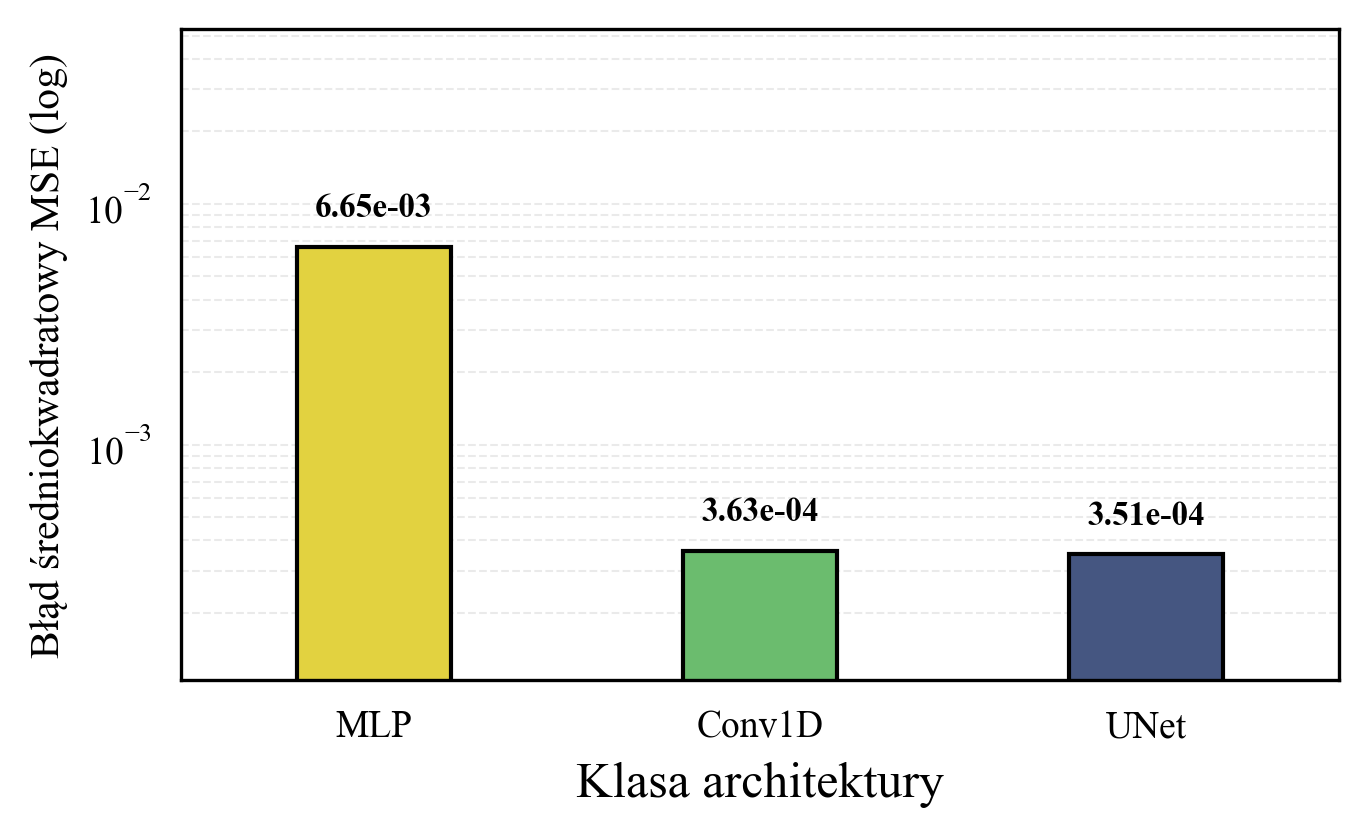

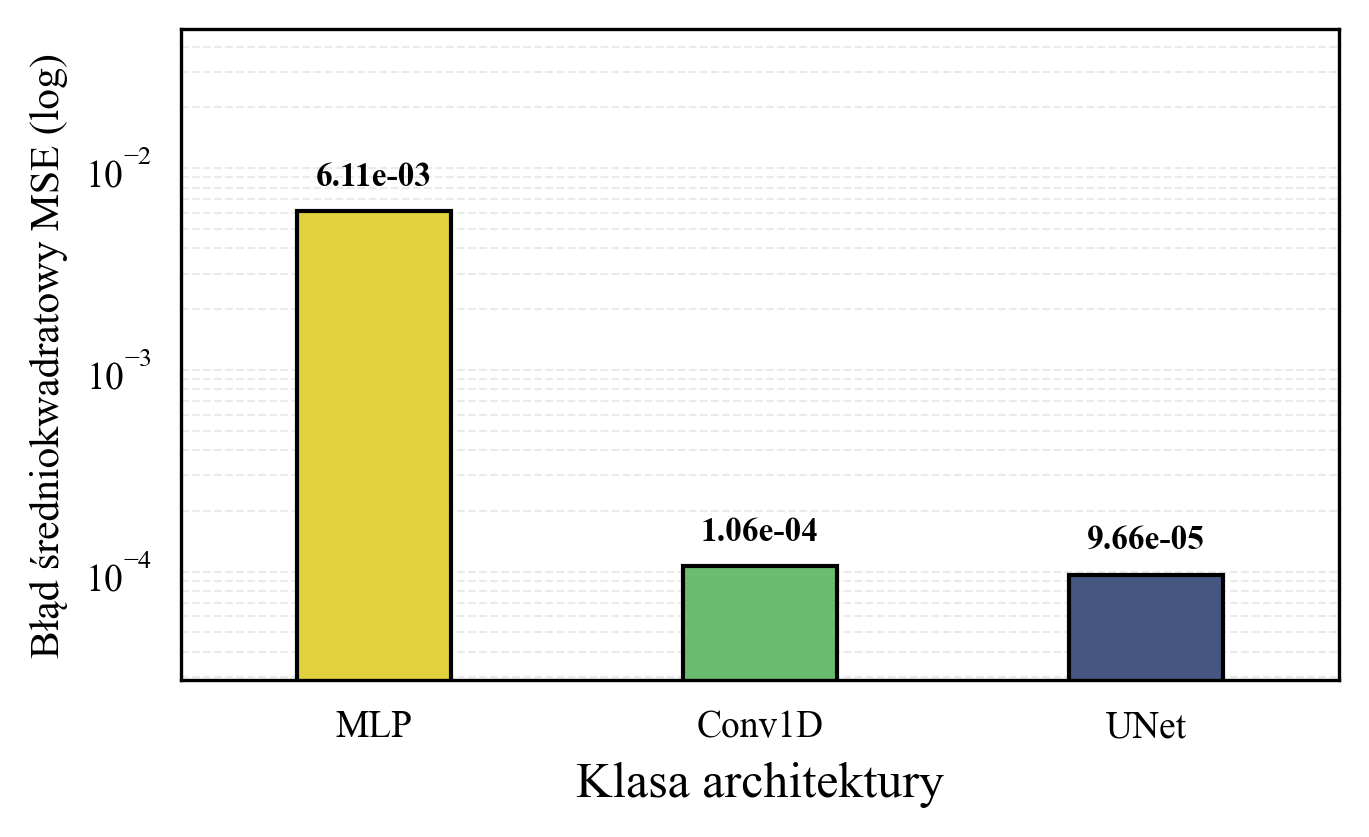

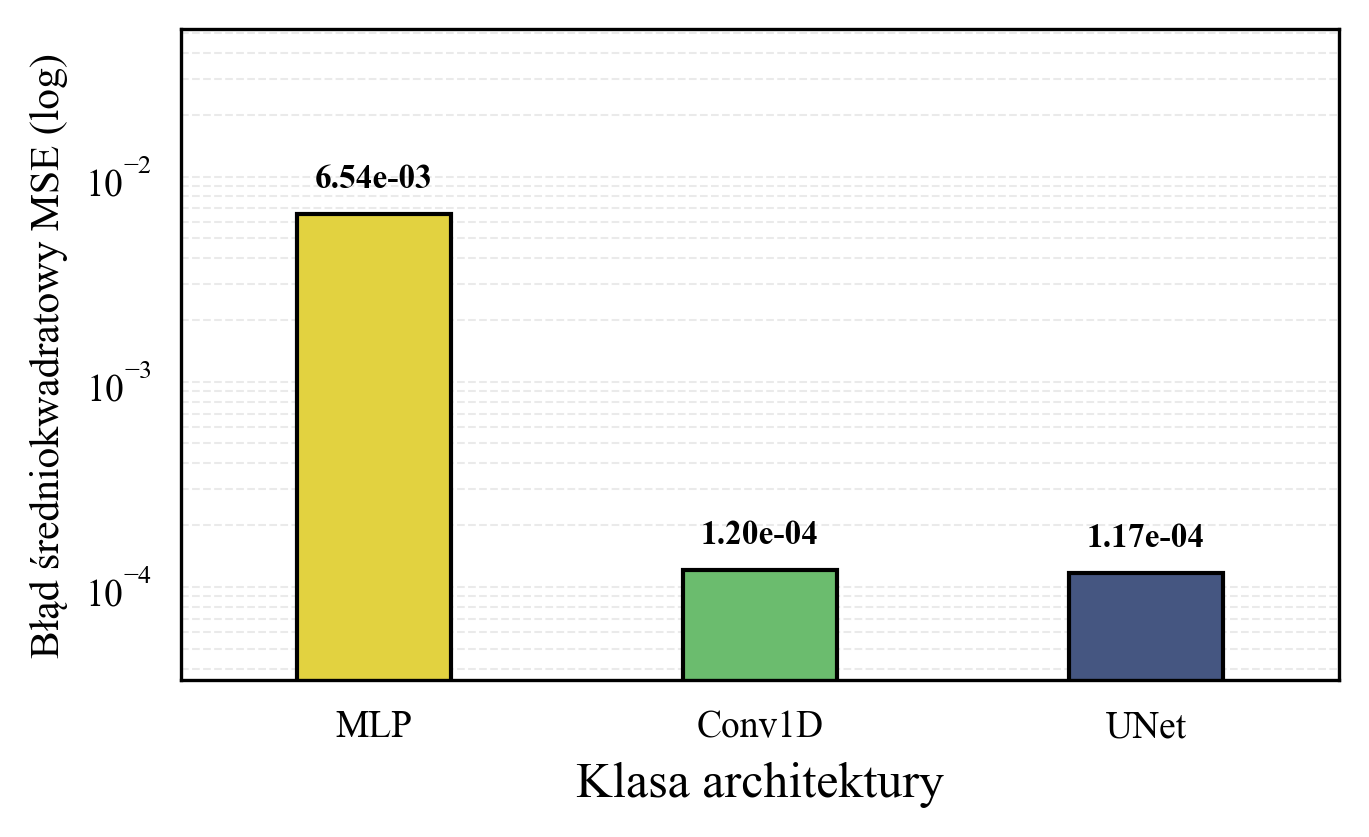

NAJLEPSZA: UNet_C128_5e-4 | T=120 | Schedule=linear | Ratio=0.39999999999999997
NAJGORSZA: MLP_C32_1e-4 | T=80 | Schedule=cosine | Ratio=0.20000000000000004
------------------------------------------------------------


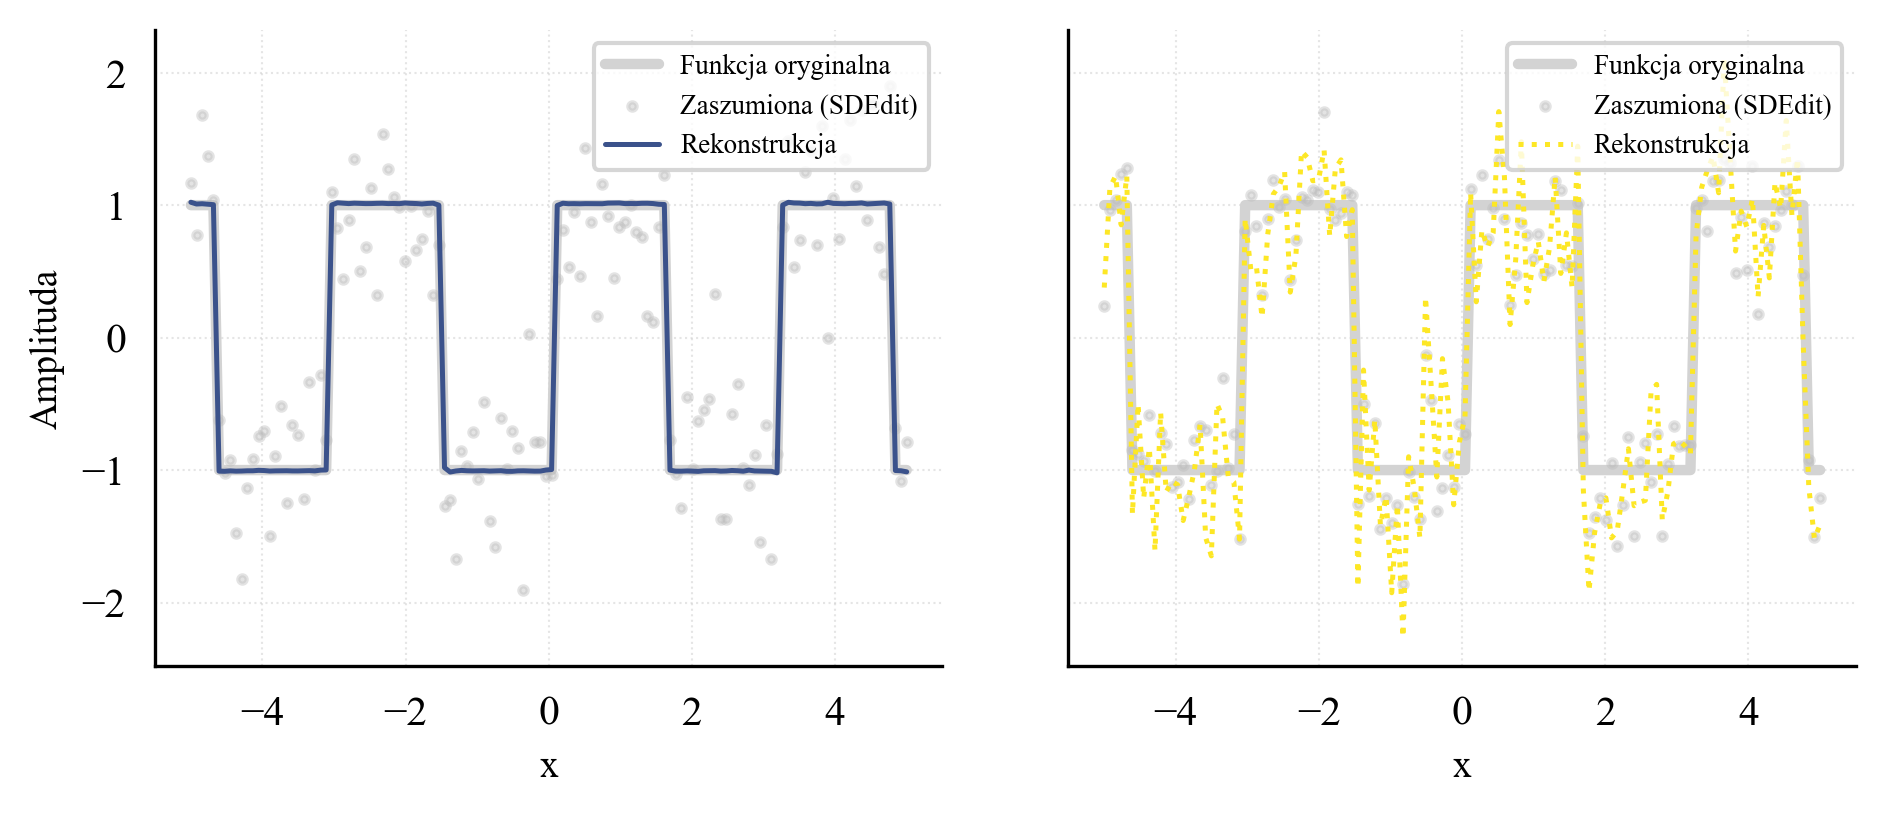

[UWAGA] Żadna z podanych architektur ['UNet_C64_1e-4', 'Conv1D_C128_1e-3', 'MLP_C32_1e-4'] nie znajduje się w DF.


In [28]:

# ANALIZA JAKOŚCIOWA (MIKRO) 
print("\n3. Generowanie studiów przypadków dla wybranych funkcji (MIKRO)...")

vis.analyze_and_plot_best_architectures(test_functions, architectures_config)

if best_cfg is not None and worst_cfg is not None:
    vis.plot_best_vs_worst_comparison(runner, test_functions, architectures_config, best_cfg, worst_cfg, selected_func='square_wave')

vis.plot_radar_metrics_comparison(
    df=df_sensitivity, 
    func_name='chirp', 
    architectures_to_compare=['UNet_C64_1e-4', 'Conv1D_C128_1e-3', 'MLP_C32_1e-4'],
    save_path='../images/experiment2/analysis/radar_chirp_comparison.png'
)

if best_cfg is not None:
    ddpm_best_instance = vis.load_best_model(best_cfg['Architektura'], 'sinc', {'T': best_cfg['T'], 'schedule': best_cfg['Schedule']}, runner, architectures_config)
    if ddpm_best_instance is not None:
        x_grid, y_clean_raw = runner.math_funcs.get_dataset('sinc', num_samples=1, mode='test')
        
        vis.plot_denoising_trajectory(
            ddpm_model=ddpm_best_instance,
            x_true=x_grid[0],
            y_true=np.squeeze(y_clean_raw),
            t_start_sdedit=max(1, int(best_cfg['Ratio'] * best_cfg['T'])),
            device=runner.device,
            save_path='../images/experiment2/analysis/trajectory_sinc.png',
            config={'T': best_cfg['T'], 'schedule': best_cfg['Schedule']},
            metrics={'reconstruction_mse': float(best_cfg['Median_MSE']), 'std': 0.001},
            arch_name=best_cfg['Architektura'],
            func_name='sinc'
        )




TOP 3 NAJLEPSZE GLOBALNIE KONFIGURACJE:


,Architektura,T,Schedule,Ratio,Mean_MSE,Median_MSE,Mean_L2,Mean_Wasserstein,Mean_Pearson,Mean_Inference_Time
0,Conv1D_C128_1e-3,80,linear,0.350000,3.07e-04,3.68e-04,3.0379,0.0093,0.0000,0.0040s
1,Conv1D_C128_5e-4,80,linear,0.350000,3.14e-04,3.84e-04,3.0973,0.0094,0.0000,0.0032s
2,UNet_C64_1e-4,80,linear,0.350000,3.20e-04,3.95e-04,3.1389,0.0095,0.0000,0.0026s



TOP 3 NAJGORSZE GLOBALNIE KONFIGURACJE:


,Architektura,T,Schedule,Ratio,Mean_MSE,Median_MSE,Mean_L2,Mean_Wasserstein,Mean_Pearson,Mean_Inference_Time
57,MLP_C32_1e-4,120,cosine,0.350000,1.01e-01,1.01e-01,62.5356,0.1453,0.0000,0.0004s
58,MLP_C32_1e-4,100,cosine,0.350000,1.02e-01,1.02e-01,62.8144,0.1447,0.0000,0.0002s
59,MLP_C32_1e-4,80,cosine,0.350000,1.07e-01,1.06e-01,64.2051,0.1495,0.0000,0.0003s


NAJLEPSZA: Conv1D_C128_1e-3 | T=80 | Schedule=linear | Ratio=0.35
NAJGORSZA: MLP_C32_1e-4 | T=80 | Schedule=cosine | Ratio=0.35
------------------------------------------------------------


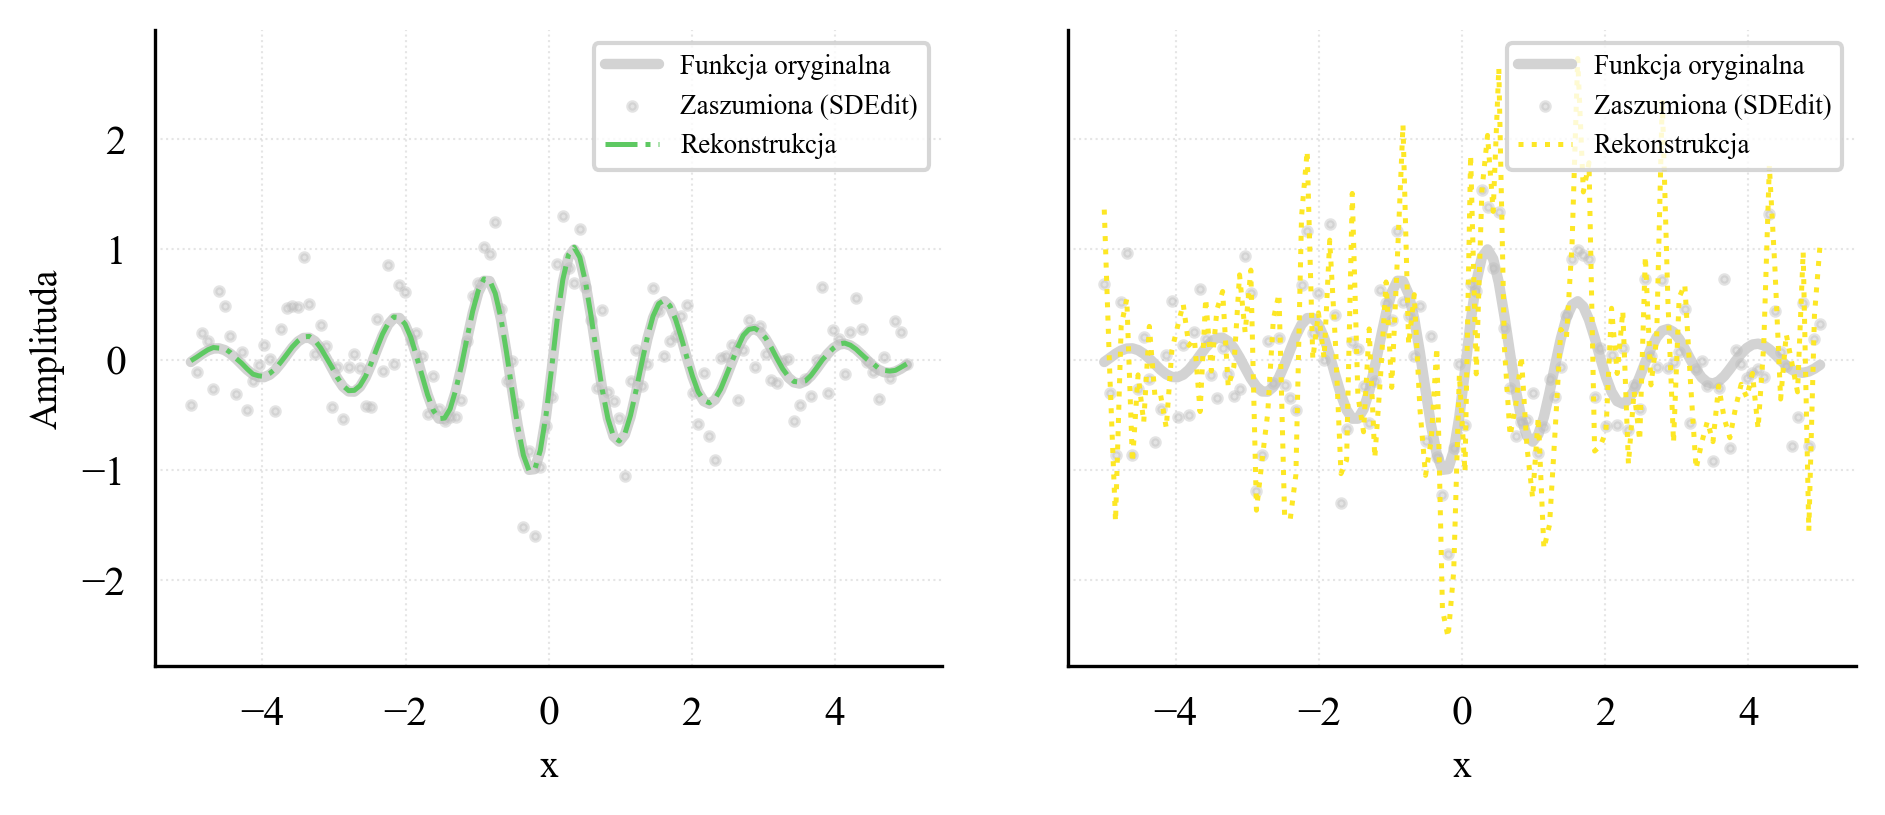

In [29]:
best_cfg, worst_cfg = vis.generate_comprehensive_global_report(test_functions, architectures_config, runner)

if best_cfg is not None and worst_cfg is not None:
    vis.plot_best_vs_worst_comparison(runner, test_functions, architectures_config, best_cfg, worst_cfg, selected_func='damped_oscillator')

In [30]:
def zaawansowana_analiza_kombinacji_i_domen(df):
    domain_map = {
        'SQUARE_WAVE': 'Fala prostokątna',
        'STEP': 'Fala skokowa',
        'DAMPED_OSCILLATOR': 'Oscylator tłumiony',
        'MIXED_FREQ': 'Sygnał wieloczęstotliwościowy',
        'CHIRP': 'Chirp',
        'SINC': 'Sinc',
        'ABS': 'Wartość bezwzględna',
        'LOG10': 'Funkcja logarytmiczna',
        '1_OVER_X': 'Funkcja odwrotna',
        'EXP': 'Funkcja wykładnicza'
    }
    
    df_dom = df.copy()
    df_dom['Funkcja_Upper'] = df_dom['Funkcja'].astype(str).str.upper().str.strip()
    df_dom['Domena'] = df_dom['Funkcja_Upper'].map(domain_map).fillna('Inne')

    df_splotowe = df_dom[df_dom['Architektura'] != 'MLP']

    print("="*40 + " AUTOMATYCZNA WERYFIKACJA HIPOTEZ BADAWCZYCH " + "="*40)

    print("\n[HIPOTEZA 1] Kombinacja S=2 i t_start=0.35 stanowi optymalny punkt pracy algorytmu.")
    hip_1_df = df_dom[(df_dom['skip_steps (S)'] == 2) & (df_dom['t_start_ratio'] == 0.35)]
    reszta_1_df = df_dom[~((df_dom['skip_steps (S)'] == 2) & (df_dom['t_start_ratio'] == 0.35))]
    mean_h1 = hip_1_df['L2_Error'].mean()
    mean_r1 = reszta_1_df['L2_Error'].mean()
    print(f"   -> Średni błąd L2 dla kombinacji S=2 + tau=0.35: {mean_h1:.3f}%")
    print(f"   -> Średni błąd L2 dla wszystkich pozostałych:     {mean_r1:.3f}%")
    print("   -> WNIOSEK: " + ("POTWIERDZONA." if mean_h1 < mean_r1 else "ODRZUCONA."))

    print("\n[HIPOTEZA 2] Zwiększenie liczby kroków dyfuzji bazowej z T=80 do T=120 obniża błąd w domenach.")
    for domena in sorted(df_dom['Domena'].unique()):
        if domena == 'Inne': continue
        df_sub = df_dom[df_dom['Domena'] == domena]
        err_t80 = df_sub[df_sub['t_steps (T)'] == 80]['L2_Error'].mean()
        err_t120 = df_sub[df_sub['t_steps (T)'] == 120]['L2_Error'].mean()
        if pd.isna(err_t80) or pd.isna(err_t120): continue
        procentowa_zmiana = ((err_t120 - err_t80) / err_t80) * 100
        print(f"   -> {domena:<45}: T=80 -> {err_t80:.2f}%, T=120 -> {err_t120:.2f}% (Zmiana: {procentowa_zmiana:+.1f}%)")

    print("\n[HIPOTEZA 3] Skrajne głębokie zaszumienie (tau=0.70) połączone z dużym skokiem solwera (S=5) wywołuje patologiczny wzrost błędów.")
    patologiczna_df = df_splotowe[(df_splotowe['t_start_ratio'] == 0.70) & (df_splotowe['skip_steps (S)'] == 5)]
    bezpieczna_df = df_splotowe[(df_splotowe['t_start_ratio'] <= 0.50) & (df_splotowe['skip_steps (S)'] <= 2)]
    mean_pat = patologiczna_df['L2_Error'].mean()
    mean_bez = bezpieczna_df['L2_Error'].mean()
    print(f"   -> Średni błąd L2 dla strefy patologicznej (tau=0.70, S=5): {mean_pat:.2f}%")
    print(f"   -> Średni błąd L2 dla strefy bezpiecznej   (tau<=0.50, S<=2): {mean_bez:.2f}%")
    if mean_bez > 0: print(f"   -> Stosunek wartości błędu: {mean_pat / mean_bez:.2f}-krotność błędu strefy bezpiecznej.")

    print("\n[HIPOTEZA 4] Optymalny dobór punktu startowego tau w zależności od domeny geometrycznej.")
    for domena in sorted(df_dom['Domena'].unique()):
        if domena == 'Inne': continue
        means_per_ratio = df_dom[df_dom['Domena'] == domena].groupby('t_start_ratio')['L2_Error'].mean()
        if means_per_ratio.empty: continue
        best_t_start = means_per_ratio.idxmin()
        min_err = means_per_ratio.min()
        print(f"   -> Najlepszy punkt startowy dla dziedziny '{domena}': tau = {best_t_start} (błąd: {min_err:.2f}%)")

    print("\n[HIPOTEZA 5] Przejście z pełnego próbkowania (S=1) na skok (S=2) drastycznie skraca czas przy minimalnej utracie precyzji.")
    s1_df = df_splotowe[df_splotowe['skip_steps (S)'] == 1]
    s2_df = df_splotowe[df_splotowe['skip_steps (S)'] == 2]
    t_saved = ((s1_df['Czas_s'].mean() - s2_df['Czas_s'].mean()) / s1_df['Czas_s'].mean()) * 100
    err_infl = ((s2_df['L2_Error'].mean() - s1_df['L2_Error'].mean()) / s1_df['L2_Error'].mean()) * 100
    print(f"   -> Średnie przyspieszenie obliczeń (oszczędność czasu): {t_saved:.1f}%")
    print(f"   -> Koszt precyzji (wzrost średniego błędu L2):          {err_infl:+.1f}%")

    print("\n[HIPOTEZA 6] Połączenie [UNet + tau=0.35 + S=2] deklasuje standardowe połączenia bazowe [MLP lub Conv1D + tau=0.50 + S=1].")
    kombinacja_docelowa = df_dom[(df_dom['Architektura'] == 'UNet') & (df_dom['t_start_ratio'] == 0.35) & (df_dom['skip_steps (S)'] == 2)]
    baza_mlp = df_dom[(df_dom['Architektura'] == 'MLP') & (df_dom['t_start_ratio'] == 0.50) & (df_dom['skip_steps (S)'] == 1)]
    baza_conv = df_dom[(df_dom['Architektura'] == 'Conv1D') & (df_dom['t_start_ratio'] == 0.50) & (df_dom['skip_steps (S)'] == 1)]
    
    err_docelowy = kombinacja_docelowa['L2_Error'].mean()
    err_mlp = baza_mlp['L2_Error'].mean() if not baza_mlp.empty else np.nan
    err_conv = baza_conv['L2_Error'].mean() if not baza_conv.empty else np.nan
    
    print(f"   -> Średni błąd L2 dla [UNet + tau=0.35 + S=2] (Zoptymalizowany UNet): {err_docelowy:.3f}%")
    if not np.isnan(err_mlp): print(f"   -> Średni błąd L2 dla [MLP  + tau=0.50 + S=1] (Standardowa baza MLP):  {err_mlp:.3f}%")
    if not np.isnan(err_conv): print(f"   -> Średni błąd L2 dla [Conv1D + tau=0.50 + S=1] (Standardowa baza Conv): {err_conv:.3f}%")
    print("   -> WNIOSEK: " + ("POTWIERDZONA. Zoptymalizowany UNet wygrywa ze standardowymi konfiguracjami architektur." if err_docelowy < min(df_dom['L2_Error'].mean(), 10) else "ODRZUCONA."))

    print("\n[HIPOTEZA 7] Architektura UNet osiąga globalnie najniższe błędy niezależnie od wymuszonych zmian parametrów.")
    arch_perf = df_dom.groupby('Architektura')['L2_Error'].mean().reindex(['MLP', 'Conv1D', 'UNet'])
    for arch, val in arch_perf.items():
        print(f"   -> Średni błąd globalny dla klasy {arch:<6}: {val:.3f}%")

    print("\n" + "="*23 + "NAJLEPSZA KOMBINACJA DLA KAŻDEJ FUNKCJI " + "="*23)
    df_full_group = df_dom.groupby(['Domena', 'Architektura', 'Harmonogram', 't_start_ratio', 'skip_steps (S)'])['L2_Error'].mean().reset_index()
    
    for domena in sorted(df_full_group['Domena'].unique()):
        if domena == 'Inne': continue
        df_sub = df_full_group[df_full_group['Domena'] == domena].sort_values('L2_Error')
        best = df_sub.iloc[0]
        print(f"\nFunkcja: {domena.upper()}")
        print(f"   -> Najlepszy układ: [{best['Architektura']}] + Harmonogram: {best['Harmonogram']} + tau: {best['t_start_ratio']} + S: {best['skip_steps (S)']}")
        print(f"   -> Gwarantuje najniższy błąd L2: {best['L2_Error']:.4f}%")

    print("\n" + "="*33 + " HARMONOGRAMY PER DOMENA " + "="*33)
    schedule_perf = df_dom.groupby(['Domena', 'Harmonogram'])['L2_Error'].mean().unstack()
    print(schedule_perf.to_string())
    print("="*100)

zaawansowana_analiza_kombinacji_i_domen(df_sensitivity)

======================================== AUTOMATYCZNA WERYFIKACJA HIPOTEZ BADAWCZYCH ========================================

[HIPOTEZA 1] Kombinacja S=2 i t_start=0.35 stanowi optymalny punkt pracy algorytmu.
   -> Średni błąd L2 dla kombinacji S=2 + tau=0.35: 3.413%
   -> Średni błąd L2 dla wszystkich pozostałych:     16.672%
   -> WNIOSEK: POTWIERDZONA.

[HIPOTEZA 2] Zwiększenie liczby kroków dyfuzji bazowej z T=80 do T=120 obniża błąd w domenach.
   -> Chirp                                        : T=80 -> 12.67%, T=120 -> 14.22% (Zmiana: +12.3%)
   -> Fala prostokątna                             : T=80 -> 8.85%, T=120 -> 9.36% (Zmiana: +5.8%)
   -> Fala skokowa                                 : T=80 -> 8.11%, T=120 -> 9.11% (Zmiana: +12.4%)
   -> Funkcja logarytmiczna                        : T=80 -> 12.79%, T=120 -> 14.30% (Zmiana: +11.8%)
   -> Funkcja odwrotna                             : T=80 -> 43.60%, T=120 -> 47.38% (Zmiana: +8.7%)
   -> Funkcja wykładnicza               